<a href="https://colab.research.google.com/github/Rohitvinoj/About-me-/blob/main/phase_1_loading_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ============================================================
# PHASE 1: DATA LOADING & STANDARDIZATION - CORRECTED
# Exactly matching your Fakeddit & Twitter data paths
# ============================================================
# Based on your working code with EXACT path configurations
# ============================================================

import os
import pandas as pd
import numpy as np
import requests
import concurrent.futures
from PIL import Image
from io import BytesIO
import logging

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# ============================================================
# CONFIGURATION - EXACT PATHS FROM YOUR CODE
# ============================================================

# Fakeddit paths (from your asasdasdas.py)
FAKEDDIT_BASE = "/content/drive/MyDrive/dataset/all_samples (also includes non multimodal)/"
TRAIN_FILE = f"{FAKEDDIT_BASE}all_train.tsv"
VALID_FILE = f"{FAKEDDIT_BASE}all_validate.tsv"
TEST_FILE = f"{FAKEDDIT_BASE}all_test_public.tsv"

# Twitter paths (from your asasdasdas.py)
TWITTER_BASE = "/content/drive/MyDrive/dataset/28516655/twitter/twitter/"
TRAIN_POSTS = f"{TWITTER_BASE}train_posts.csv"
TEST_POSTS = f"{TWITTER_BASE}test_posts.csv"
EXTRA_TRAIN = f"{TWITTER_BASE}df_train2.csv"
EXTRA_TEST = f"{TWITTER_BASE}df_test2.csv"
TRAIN_FEATURES = f"{TWITTER_BASE}train_posts_features.txt"
TEST_FEATURES = f"{TWITTER_BASE}test_post_features.txt"
IMAGE_TRAIN_DIR = f"{TWITTER_BASE}images_train/"
IMAGE_TEST_DIR = f"{TWITTER_BASE}images_test/"

# Output paths
OUTPUT_DIR = "/content/phase1_data"
FAKEDDIT_IMAGES_DIR = "/content/fakeddit_images"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FAKEDDIT_IMAGES_DIR, exist_ok=True)

# ============================================================
# PHASE 1A: LOAD FAKEDDIT DATA
# ============================================================

class FakedditLoader:
    """Load and standardize Fakeddit dataset with configurable label mapping."""

    MAPPING_OPTIONS = {
        1: "Standard (True=1, others=0)",
        2: "Conservative (True+Satire=Real) - RECOMMENDED",
        3: "Aggressive (Malicious fakes only)",
        4: "Veracity-Based (True only)",
        5: "Semantic-Based (True+Satire real)"
    }

    def __init__(self, mapping_option: int = 2):
        self.mapping_option = mapping_option
        logger.info(f"Fakeddit Loader initialized with option {mapping_option}: {self.MAPPING_OPTIONS[mapping_option]}")

    def reduce_label(self, x: int) -> int:
        """Convert 6-way label to binary based on selected mapping."""
        if self.mapping_option == 1:
            return 1 if x == 1 else 0
        elif self.mapping_option == 2:
            # True (1) + Satire (2) = Real; others = Fake
            return 1 if x in [1, 2] else 0
        elif self.mapping_option == 3:
            # Only include malicious fakes as fake
            return 0 if x in [3, 4, 6] else 1
        elif self.mapping_option == 4:
            return 1 if x == 1 else 0
        elif self.mapping_option == 5:
            return 0 if x in [3, 4, 6] else 1
        return 1

    def load(self) -> pd.DataFrame:
        """Load and process Fakeddit dataset."""
        logger.info("📌 Loading Fakeddit Dataset...")

        try:
            # STEP 1: Load TSV files
            logger.info("Loading TSV files...")
            train = pd.read_csv(TRAIN_FILE, sep="\t", encoding="utf-8")
            valid = pd.read_csv(VALID_FILE, sep="\t", encoding="utf-8")
            test = pd.read_csv(TEST_FILE, sep="\t", encoding="utf-8")

            logger.info(f"✓ all_train.tsv: {len(train)} rows")
            logger.info(f"✓ all_validate.tsv: {len(valid)} rows")
            logger.info(f"✓ all_test_public.tsv: {len(test)} rows")

            # STEP 2: Add split identifier
            train["split"] = "train"
            valid["split"] = "valid"
            test["split"] = "test"
            fakeddit_df = pd.concat([train, valid, test], ignore_index=True)
            logger.info(f"✓ Fakeddit consolidated: {len(fakeddit_df)} rows")

            # STEP 3: Standardize columns
            logger.info("Standardizing columns...")
            fakeddit_df["id"] = fakeddit_df["id"].astype(str)
            fakeddit_df["text"] = fakeddit_df["clean_title"].fillna("").astype(str)
            fakeddit_df["dataset"] = "fakeddit"

            # STEP 4: Map labels
            logger.info(f"Mapping labels with option {self.mapping_option}...")
            fakeddit_df["6_way_label"] = fakeddit_df["6_way_label"].astype(int)
            fakeddit_df["3_way_label"] = fakeddit_df["3_way_label"].astype(int)
            fakeddit_df["2_way_label"] = fakeddit_df["2_way_label"].astype(int)
            fakeddit_df["label"] = fakeddit_df["6_way_label"].apply(self.reduce_label)

            logger.info(f"✓ Fake (0): {(fakeddit_df['label']==0).sum()}")
            logger.info(f"✓ Real (1): {(fakeddit_df['label']==1).sum()}")

            # STEP 5: Handle images
            logger.info("Processing image information...")
            fakeddit_df["image_exists"] = fakeddit_df["hasImage"].fillna(False).astype(bool)
            fakeddit_df["image_url_original"] = fakeddit_df["image_url"].fillna("")
            fakeddit_df["image_path"] = None
            fakeddit_df["image_id"] = fakeddit_df["id"]

            total_images = fakeddit_df["image_exists"].sum()
            pct = 100 * total_images / len(fakeddit_df)
            logger.info(f"✓ Image coverage: {total_images} images ({pct:.1f}%)")

            # STEP 6: Download images
            logger.info("Downloading images...")
            self._download_images(fakeddit_df)

            # STEP 7: Social features
            logger.info("Extracting social features...")
            self._add_social_features(fakeddit_df)

            # STEP 8: Timestamp
            logger.info("Processing timestamps...")
            if "created_utc" in fakeddit_df.columns:
                fakeddit_df["created_at"] = pd.to_datetime(
                    fakeddit_df["created_utc"], unit="s", errors="coerce"
                )
            else:
                fakeddit_df["created_at"] = pd.NaT

            # STEP 9: Final columns
            return_cols = [
                'id', 'text', 'label', 'dataset', 'created_at', 'split',
                'image_exists', 'image_path',
                'text_length', 'num_words', 'punct_score',
                'has_image', 'score', 'num_comments', 'upvote_ratio'
            ]
            existing = [c for c in return_cols if c in fakeddit_df.columns]
            result = fakeddit_df[existing].copy()

            logger.info(f"✓ Fakeddit final shape: {result.shape}")
            return result

        except Exception as e:
            logger.error(f"❌ Error loading Fakeddit: {e}")
            import traceback
            traceback.print_exc()
            return pd.DataFrame()

    def _download_images(self, df: pd.DataFrame, num_to_download: int = 1000):
        """Download Fakeddit images concurrently."""
        df_images = df[df["image_url_original"] != ""].copy()
        df_images = df_images.sample(min(num_to_download, len(df_images)), random_state=42)

        for s in ["train", "valid", "test"]:
            os.makedirs(f"{FAKEDDIT_IMAGES_DIR}/{s}", exist_ok=True)

        def download_single(row):
            url = row["image_url_original"]
            img_id = row["id"]
            sp = row["split"]
            save_path = f"{FAKEDDIT_IMAGES_DIR}/{sp}/{img_id}.jpg"

            if os.path.exists(save_path):
                return img_id, save_path

            try:
                r = requests.get(url, timeout=10)
                img = Image.open(BytesIO(r.content)).convert("RGB")
                img.save(save_path, "JPEG")
                return img_id, save_path
            except:
                return img_id, None

        results = []
        with concurrent.futures.ThreadPoolExecutor(max_workers=20) as exe:
            for r in exe.map(download_single, [row for _, row in df_images.iterrows()]):
                results.append(r)

        for img_id, p in results:
            df.loc[df["id"] == img_id, "image_path"] = p

        logger.info(f"✓ Downloaded {len([r for r in results if r[1]])} images")

    def _add_social_features(self, df: pd.DataFrame):
        """Add social feature columns."""
        df["text_length"] = df["text"].str.len()
        df["num_words"] = df["text"].str.split().str.len()

        # Punctuation score
        punct_chars = df["text"].apply(
            lambda x: sum(1 for c in str(x) if c in '!\"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~')
        )
        df["punct_score"] = (punct_chars / df["text_length"].clip(lower=1)).fillna(0)
        df["has_image"] = df["image_exists"].astype(int)

# ============================================================
# PHASE 1B: LOAD TWITTER DATA
# ============================================================

class TwitterLoader:
    """Load and standardize Twitter dataset."""

    def load(self) -> pd.DataFrame:
        """Load and process Twitter dataset."""
        logger.info("📌 Loading Twitter Dataset...")

        try:
            # STEP 1: Load CSV files
            logger.info("Loading CSV files...")
            train_posts = pd.read_csv(TRAIN_POSTS)
            test_posts = pd.read_csv(TEST_POSTS)

            # Load extra samples
            df_train2 = pd.read_csv(EXTRA_TRAIN)
            df_test2 = pd.read_csv(EXTRA_TEST)

            train_posts = pd.concat([train_posts, df_train2], ignore_index=True)
            test_posts = pd.concat([test_posts, df_test2], ignore_index=True)

            logger.info(f"✓ train_posts: {len(train_posts)} rows (including df_train2)")
            logger.info(f"✓ test_posts: {len(test_posts)} rows (including df_test2)")

            # STEP 2: Load features
            logger.info("Loading feature files...")
            train_features = pd.read_csv(TRAIN_FEATURES, skipinitialspace=True)
            test_features = pd.read_csv(TEST_FEATURES, skipinitialspace=True)

            logger.info(f"✓ train_features: {len(train_features)} rows")
            logger.info(f"✓ test_features: {len(test_features)} rows")

            # STEP 3: Merge
            logger.info("Merging posts with features...")
            train_merged = train_posts.merge(train_features, on='post_id', how='left')
            test_merged = test_posts.merge(test_features, on='post_id', how='left')

            train_merged['split'] = 'train'
            test_merged['split'] = 'test'

            twitter_df = pd.concat([train_merged, test_merged], ignore_index=True)
            logger.info(f"✓ Twitter consolidated: {len(twitter_df)} rows")

            # STEP 4: Standardize columns
            logger.info("Standardizing columns...")
            twitter_df['id'] = twitter_df['post_id'].astype(str)
            twitter_df['text'] = twitter_df['post_text'].astype(str)
            twitter_df['dataset'] = 'twitter'

            # Map labels
            if 'label' in twitter_df.columns:
                twitter_df['label'] = twitter_df['label'].apply(
                    lambda x: 0 if str(x).lower() == 'fake' else 1
                )
            else:
                twitter_df['label'] = 1

            # STEP 5: Timestamps
            if 'timestamp' in twitter_df.columns:
                twitter_df['created_at'] = pd.to_datetime(twitter_df['timestamp'], errors='coerce')
            else:
                twitter_df['created_at'] = pd.NaT

            # STEP 6: Image verification
            logger.info("Verifying and mapping images...")

            def find_image(row):
                if pd.isna(row.get('image_id')) or row.get('image_id') == '':
                    return False, None

                img_id = str(row['image_id']).strip()
                search_dir = IMAGE_TRAIN_DIR if row['split'] == 'train' else IMAGE_TEST_DIR

                for ext in ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']:
                    full_path = os.path.join(search_dir, f"{img_id}{ext}")
                    if os.path.exists(full_path):
                        return True, full_path

                return False, None

            twitter_df[['image_exists', 'image_path']] = twitter_df.apply(
                lambda row: pd.Series(find_image(row)), axis=1
            )

            found = twitter_df['image_exists'].sum()
            logger.info(f"✓ Images found: {found} ({100*found/len(twitter_df):.1f}%)")

            # STEP 7: Social features
            logger.info("Extracting social features...")
            self._add_social_features(twitter_df)

            # STEP 8: Final columns
            return_cols = [
                'id', 'text', 'label', 'dataset', 'created_at', 'split',
                'image_exists', 'image_path',
                'text_length', 'num_words', 'punct_score', 'has_image'
            ]
            existing = [c for c in return_cols if c in twitter_df.columns]
            result = twitter_df[existing].copy()

            logger.info(f"✓ Twitter final shape: {result.shape}")
            return result

        except Exception as e:
            logger.error(f"❌ Error loading Twitter: {e}")
            import traceback
            traceback.print_exc()
            return pd.DataFrame()

    def _add_social_features(self, df: pd.DataFrame):
        """Add social feature columns."""
        df["text_length"] = df["text"].str.len()
        df["num_words"] = df["text"].str.split().str.len()

        punct_chars = df["text"].apply(
            lambda x: sum(1 for c in str(x) if c in '!\"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~')
        )
        df["punct_score"] = (punct_chars / df["text_length"].clip(lower=1)).fillna(0)
        df["has_image"] = df["image_exists"].astype(int)

# ============================================================
# PHASE 1C: UNIFIED STANDARDIZATION
# ============================================================

def standardize_unified(fakeddit_df: pd.DataFrame, twitter_df: pd.DataFrame) -> pd.DataFrame:
    """Combine and standardize both datasets to unified schema."""

    logger.info("Standardizing unified schema...")

    # Ensure both have same columns
    required_cols = [
        'id', 'text', 'label', 'dataset', 'created_at', 'split',
        'image_exists', 'image_path',
        'text_length', 'num_words', 'punct_score', 'has_image'
    ]

    fakeddit_df = fakeddit_df[[c for c in required_cols if c in fakeddit_df.columns]]
    twitter_df = twitter_df[[c for c in required_cols if c in twitter_df.columns]]

    # Combine
    unified_df = pd.concat([fakeddit_df, twitter_df], ignore_index=True)

    # Remove nulls
    unified_df = unified_df.dropna(subset=['id', 'text', 'label'])

    logger.info(f"✓ Unified dataset: {len(unified_df)} samples")
    logger.info(f"✓ Fake (0): {(unified_df['label']==0).sum()}")
    logger.info(f"✓ Real (1): {(unified_df['label']==1).sum()}")

    return unified_df

# ============================================================
# MAIN EXECUTION
# ============================================================

def main_phase1(use_fakeddit: bool = True, use_twitter: bool = True) -> pd.DataFrame:
    """Main Phase 1 execution."""

    logger.info("="*70)
    logger.info("PHASE 1: DATA LOADING & STANDARDIZATION")
    logger.info("="*70)

    dfs = []

    # Load Fakeddit
    if use_fakeddit:
        fakeddit_loader = FakedditLoader(mapping_option=2)
        fakeddit_df = fakeddit_loader.load()
        if len(fakeddit_df) > 0:
            dfs.append(fakeddit_df)

    # Load Twitter
    if use_twitter:
        twitter_loader = TwitterLoader()
        twitter_df = twitter_loader.load()
        if len(twitter_df) > 0:
            dfs.append(twitter_df)

    # Unify
    if dfs:
        unified_df = pd.concat(dfs, ignore_index=True)
    else:
        logger.error("No datasets loaded!")
        return pd.DataFrame()

    # Save
    output_path = os.path.join(OUTPUT_DIR, "phase1_standardized.csv")
    unified_df.to_csv(output_path, index=False)
    logger.info(f"✓ Saved to {output_path}")

    logger.info("="*70)
    logger.info("PHASE 1 COMPLETE")
    logger.info("="*70)

    return unified_df

if __name__ == "__main__":
    df = main_phase1(use_fakeddit=True, use_twitter=True)
    print(f"\nFinal shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    print(f"\nFirst 5 rows:")
    print(df.head())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.3/189.3 kB 5.0 MB/s eta 0:00:00


,id,text,label,dataset,created_at,split,image_exists,image_path,text_length,num_words,punct_score,has_image
0,awxhir,my walgreens offbrand mucinex was engraved wit...,0,fakeddit,2019-03-03 19:27:24,train,1,NaN,92,15,0.0,1
1,cvm5uy4,NaN,0,fakeddit,2015-10-02 21:45:26,train,1,NaN,0,0,0.0,1
2,98pbid,this concerned sink with a tiny hat,1,fakeddit,2018-08-20 01:10:13,train,1,NaN,35,7,0.0,1
3,6f2cy5,hackers leak emails from uae ambassador to us,0,fakeddit,2017-06-03 17:26:38,train,1,/content/fakeddit_images/train/6f2cy5.jpg,45,8,0.0,1
4,cc5cbon,NaN,0,fakeddit,2013-09-10 05:46:21,train,1,NaN,0,0,0.0,1


In [ ]:
# ============================================================
# BLOCK 1: LOAD FAKEDDIT DATASET (Jupyter-friendly version)
# ============================================================

import os
import logging
import pandas as pd
import numpy as np
import concurrent.futures
import requests
from PIL import Image
from io import BytesIO

logging.basicConfig(level=logging.INFO)
log = logging.getLogger("FAKEDDIT")

# -----------------------------
# CONFIG
# -----------------------------
FAKEDDIT_BASE = "/content/drive/MyDrive/dataset/all_samples (also includes non multimodal)/"
TRAIN_FILE = f"{FAKEDDIT_BASE}all_train.tsv"
VALID_FILE = f"{FAKEDDIT_BASE}all_validate.tsv"
TEST_FILE  = f"{FAKEDDIT_BASE}all_test_public.tsv"
FAKEDDIT_IMG_DIR = "/content/fakeddit_images"

os.makedirs(FAKEDDIT_IMG_DIR, exist_ok=True)

MAX_ROWS = 9000              # limit number of rows loaded (None = load all)
MAX_IMAGES_FAKEDDIT = 9999   # limit image downloads
MAPPING_OPTION = 2           # default mapping scheme (your original recommendation)

# -----------------------------
# Full Label Mapping System
# -----------------------------
MAPPING_OPTIONS = {
    1: "Standard (True=1, others=0)",
    2: "Conservative (True+Satire=Real) - RECOMMENDED",
    3: "Aggressive (Malicious fakes only)",
    4: "Veracity-Based (True only)",
    5: "Semantic-Based (True+Satire real)"
}

def reduce_fakeddit_label(x: int, option: int = 2) -> int:
    """Convert 6-way Fakeddit label → binary using mapping rules."""
    x = int(x)

    if option == 1:
        return 1 if x == 1 else 0

    elif option == 2:
        # True (1) + Satire (2) = Real
        return 1 if x in [1, 2] else 0

    elif option == 3:
        # Malicious fakes only
        return 0 if x in [3, 4, 6] else 1

    elif option == 4:
        # Strict veracity
        return 1 if x == 1 else 0

    elif option == 5:
        # Semantic grouping
        return 0 if x in [3, 4, 6] else 1

    return 1

# -----------------------------
# Download image helper
# -----------------------------
def download_image(row):
    url = row["image_url_original"]
    img_id = row["id"]
    split = row["split"]

    save_dir = f"{FAKEDDIT_IMG_DIR}/{split}"
    os.makedirs(save_dir, exist_ok=True)

    save_path = f"{save_dir}/{img_id}.jpg"

    # Skip if already exists
    if os.path.exists(save_path):
        return img_id, save_path

    try:
        r = requests.get(url, timeout=10)
        r.raise_for_status()
        img = Image.open(BytesIO(r.content)).convert("RGB")
        img.save(save_path, "JPEG")
        return img_id, save_path
    except:
        return img_id, None

# -----------------------------
# MAIN LOADER
# -----------------------------
def load_fakeddit(max_rows=MAX_ROWS, max_images=MAX_IMAGES_FAKEDDIT, mapping_option=MAPPING_OPTION):
    log.info("📌 Loading Fakeddit...")
    log.info(f"Using mapping option {mapping_option}: {MAPPING_OPTIONS[mapping_option]}")

    # Load TSVs
    train = pd.read_csv(TRAIN_FILE, sep="\t")
    valid = pd.read_csv(VALID_FILE, sep="\t")
    test  = pd.read_csv(TEST_FILE,  sep="\t")

    # Row limits
    if max_rows:
        train = train.head(max_rows)
        valid = valid.head(max_rows)
        test  = test.head(max_rows)

    # Tag splits
    train["split"] = "train"
    valid["split"] = "valid"
    test["split"]  = "test"

    df = pd.concat([train, valid, test], ignore_index=True)
    df["dataset"] = "fakeddit"

    # Text
    df["text"] = df["clean_title"].fillna("").astype(str)

    # Labels (with mapping options)
    df["label"] = df["6_way_label"].apply(lambda x: reduce_fakeddit_label(x, mapping_option))

    # Image metadata
    df["image_exists"] = df["hasImage"].astype(bool)
    df["image_url_original"] = df["image_url"].fillna("")
    df["image_path"] = None
    df["image_id"] = df["id"].astype(str)

    # Download subset of images
    df_imgs = df[df["image_url_original"] != ""]
    imgs = df_imgs.sample(min(max_images, len(df_imgs)), random_state=42)

    with concurrent.futures.ThreadPoolExecutor(max_workers=15) as exe:
        results = list(exe.map(download_image, [r for _, r in imgs.iterrows()]))

    for img_id, path in results:
        df.loc[df["id"] == img_id, "image_path"] = path

    # Social features
    df["text_length"] = df["text"].str.len()
    df["num_words"] = df["text"].str.split().str.len()
    df["punct_score"] = df["text"].apply(
        lambda x: sum(1 for c in str(x) if c in "!\"#$%&'()*+,-./:;<=>?@[]^_`{|}~")
    ) / df["text_length"].clip(lower=1)

    df["has_image"] = df["image_exists"].astype(int)

    # Timestamp
    if "created_utc" in df.columns:
        df["created_at"] = pd.to_datetime(df["created_utc"], unit="s")
    else:
        df["created_at"] = pd.NaT

    log.info(f"✓ Loaded Fakeddit: {df.shape}")
    return df

# -----------------------------
# RUN BLOCK 1
# -----------------------------
fakeddit_df = load_fakeddit()
fakeddit_df.head()


,Unnamed: 0.2,Unnamed: 0,Unnamed: 0.1,Unnamed: 0.1.1,author,clean_title,created_utc,domain,hasImage,id,...,label,image_exists,image_url_original,image_path,image_id,text_length,num_words,punct_score,has_image,created_at
0,0,0,NaN,NaN,Alexithymia,my walgreens offbrand mucinex was engraved wit...,1.551641e+09,i.imgur.com,True,awxhir,...,0,True,https://external-preview.redd.it/WylDbZrnbvZdB...,None,awxhir,92,15,0.0,1,2019-03-03 19:27:24
1,1,1,155885.0,714550.0,RickSisco,NaN,1.443822e+09,NaN,True,cvm5uy4,...,0,True,http://i.imgur.com/yxrkYT8.jpg,None,cvm5uy4,0,0,0.0,1,2015-10-02 21:45:26
2,2,2,NaN,NaN,VIDCAs17,this concerned sink with a tiny hat,1.534727e+09,i.redd.it,True,98pbid,...,1,True,https://preview.redd.it/wsfx0gp0f5h11.jpg?widt...,None,98pbid,35,7,0.0,1,2018-08-20 01:10:13
3,3,3,NaN,NaN,prometheus1123,hackers leak emails from uae ambassador to us,1.496511e+09,aljazeera.com,True,6f2cy5,...,0,True,https://external-preview.redd.it/6fNhdbc6K1vFA...,/content/fakeddit_images/train/6f2cy5.jpg,6f2cy5,45,8,0.0,1,2017-06-03 17:26:38
4,4,4,282323.0,1228398.0,NaN,NaN,1.378792e+09,NaN,True,cc5cbon,...,0,True,http://i.imgur.com/M8KTWMx.jpg,None,cc5cbon,0,0,0.0,1,2013-09-10 05:46:21



[3] ID: 6f2cy5  Label: 0  Split: train
Image Path: /content/fakeddit_images/train/6f2cy5.jpg
Text: hackers leak emails from uae ambassador to us


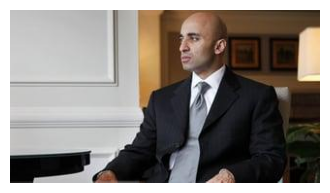


[6] ID: 4xypkv  Label: 0  Split: train
Image Path: /content/fakeddit_images/train/4xypkv.jpg
Text: puppy taking in the view


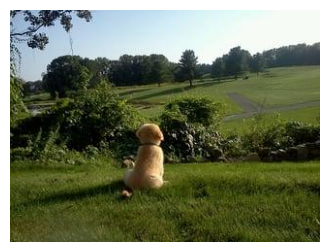


[17] ID: 4zd1tb  Label: 0  Split: train
Image Path: /content/fakeddit_images/train/4zd1tb.jpg
Text: english village becomes climate leader by quietly cleaning up its own patch


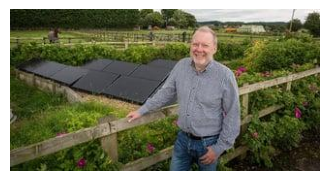


[21] ID: 796d3z  Label: 0  Split: train
Image Path: /content/fakeddit_images/train/796d3z.jpg
Text: cutest baby cow ive seen in my head all day and just enjoy destiny for what it is


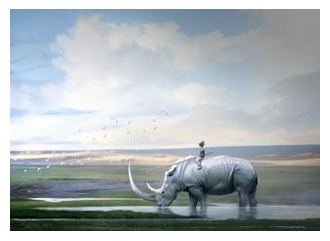


[25] ID: bjmfr7  Label: 0  Split: train
Image Path: /content/fakeddit_images/train/bjmfr7.jpg
Text: the way the rain made a silhouette of my bike


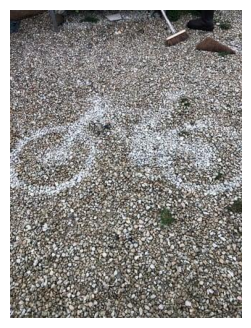

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

N = 5  # number of images to preview
samples = fakeddit_df[fakeddit_df["image_path"].notna()].head(N)

for i, row in samples.iterrows():
    print(f"\n[{i}] ID: {row['id']}  Label: {row['label']}  Split: {row['split']}")
    print("Image Path:", row["image_path"])
    print("Text:", row["text"])

    img = Image.open(row["image_path"])

    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.axis('off')
    plt.show()


In [ ]:
# ============================================================
# BLOCK 2: LOAD TWITTER DATASET (Now supports TRAIN + TEST images)
# ============================================================

import os
import logging
import pandas as pd

logging.basicConfig(level=logging.INFO)
log = logging.getLogger("TWITTER")

# -----------------------------
# CONFIG
# -----------------------------
TWITTER_BASE = "/content/drive/MyDrive/dataset/28516655/twitter/twitter/"

TRAIN_POSTS = f"{TWITTER_BASE}train_posts.csv"
TEST_POSTS  = f"{TWITTER_BASE}test_posts.csv"

EXTRA_TRAIN = f"{TWITTER_BASE}df_train2.csv"
EXTRA_TEST  = f"{TWITTER_BASE}df_test2.csv"

TRAIN_FEATURES = f"{TWITTER_BASE}train_posts_features.txt"
TEST_FEATURES  = f"{TWITTER_BASE}test_post_features.txt"

IMAGE_TRAIN_DIR = f"{TWITTER_BASE}images_train/"
IMAGE_TEST_DIR  = f"{TWITTER_BASE}images_test/"

MAX_ROWS = 9999


# -----------------------------
# Helper: Social features
# -----------------------------
def add_text_features(df):
    df["text_length"] = df["text"].str.len().fillna(0).astype(int)
    df["num_words"] = df["text"].str.split().str.len().fillna(0).astype(int)

    df["punct_score"] = df["text"].apply(
        lambda x: sum(1 for c in str(x) if c in "!\"#$%&'()*+,-./:;<=>?@[]^_`{|}~")
    ) / df["text_length"].clip(lower=1)

    df["has_image"] = df["image_exists"].astype(int)
    return df


# -----------------------------
# MAIN LOADER
# -----------------------------
def load_twitter(max_rows=MAX_ROWS):
    log.info("📌 Loading Twitter...")

    # ========= Load posts =========
    train = pd.read_csv(TRAIN_POSTS)
    test  = pd.read_csv(TEST_POSTS)

    if max_rows:
        train = train.head(max_rows)
        test  = test.head(max_rows)

    # ========= Extra samples =========
    df_train2 = pd.read_csv(EXTRA_TRAIN)
    df_test2  = pd.read_csv(EXTRA_TEST)

    if max_rows:
        df_train2 = df_train2.head(max_rows)
        df_test2  = df_test2.head(max_rows)

    # Combine train/test sets
    train = pd.concat([train, df_train2], ignore_index=True)
    test  = pd.concat([test,  df_test2], ignore_index=True)

    # ========= Load features =========
    try:
        train_feats = pd.read_csv(TRAIN_FEATURES, skipinitialspace=True)
        test_feats  = pd.read_csv(TEST_FEATURES,  skipinitialspace=True)
    except:
        train_feats = pd.read_csv(TRAIN_FEATURES, sep=None, engine="python")
        test_feats  = pd.read_csv(TEST_FEATURES,  sep=None, engine="python")

    # ========= Merge =========
    train_merged = train.merge(train_feats, on="post_id", how="left")
    test_merged  = test.merge(test_feats,  on="post_id", how="left")

    train_merged["split"] = "train"
    test_merged["split"]  = "test"

    df = pd.concat([train_merged, test_merged], ignore_index=True)
    df["dataset"] = "twitter"

    # ========= Text =========
    df["id"] = df["post_id"].astype(str)
    df["text"] = df["post_text"].fillna("").astype(str)

    # ========= Labels =========
    if "label" in df.columns:
        df["label"] = df["label"].apply(lambda x: 0 if str(x).lower() == "fake" else 1)
    else:
        df["label"] = 1

    df["label"] = df["label"].fillna(1).astype(int)

    # ========= Timestamp =========
    df["created_at"] = pd.to_datetime(df.get("timestamp"), errors="coerce")

    # ========= Image ID =========
    df["image_id"] = df.get("image_id", "").fillna("").astype(str).str.lower().str.strip()

    # =====================================================
    # BUILD LOOKUP TABLES FOR BOTH DIRECTORIES
    # =====================================================
    image_map_train = {}
    if os.path.isdir(IMAGE_TRAIN_DIR):
        for fname in os.listdir(IMAGE_TRAIN_DIR):
            base, ext = os.path.splitext(fname)
            if ext.lower() == ".jpg":
                image_map_train[base.lower()] = os.path.join(IMAGE_TRAIN_DIR, fname)

    image_map_test = {}
    if os.path.isdir(IMAGE_TEST_DIR):
        for fname in os.listdir(IMAGE_TEST_DIR):
            base, ext = os.path.splitext(fname)
            if ext.lower() == ".jpg":
                image_map_test[base.lower()] = os.path.join(IMAGE_TEST_DIR, fname)

    log.info(f"Train image files found: {len(image_map_train)}")
    log.info(f"Test image files found:  {len(image_map_test)}")

    # =====================================================
    # MAP IMAGES BY SPLIT
    # =====================================================

    def find_image(row):
        img_id = row["image_id"]
        if img_id == "":
            return None
        if row["split"] == "train":
            return image_map_train.get(img_id, None)
        else:
            return image_map_test.get(img_id, None)

    df["image_path"] = df.apply(find_image, axis=1)
    df["image_exists"] = df["image_path"].notna().astype(int)

    # ========= Social Features =========
    df = add_text_features(df)

    log.info(f"✓ Loaded Twitter: {df.shape}")
    return df


# -----------------------------
# RUN BLOCK 2
# -----------------------------
twitter_df = load_twitter()
twitter_df.head()


,post_id,post_text,user_id,image_id,username,timestamp,label,num_words,text_length,contains_questmark,...,num_retweets,split,dataset,id,text,created_at,image_path,image_exists,punct_score,has_image
0,324597532548276224,Don't need feds to solve the #bostonbombing wh...,886672620.0,boston_fake_03,SantaCruzShred,Wed Apr 17 18:57:37 +0000 2013,0,12,88,False,...,0.0,train,twitter,324597532548276224,Don't need feds to solve the #bostonbombing wh...,2013-04-17 18:57:37+00:00,/content/drive/MyDrive/dataset/28516655/twitte...,1,0.113636,1
1,325145334739267584,PIC: Comparison of #Boston suspect Sunil Tripa...,21992286.0,boston_fake_23,Oscar_Wang,Fri Apr 19 07:14:23 +0000 2013,0,16,135,False,...,0.0,train,twitter,325145334739267584,PIC: Comparison of #Boston suspect Sunil Tripa...,2013-04-19 07:14:23+00:00,/content/drive/MyDrive/dataset/28516655/twitte...,1,0.081481,1
2,325152091423248385,I'm not completely convinced that it's this Su...,16428755.0,boston_fake_34,jamwil,Fri Apr 19 07:41:14 +0000 2013,0,10,88,False,...,0.0,train,twitter,325152091423248385,I'm not completely convinced that it's this Su...,2013-04-19 07:41:14+00:00,/content/drive/MyDrive/dataset/28516655/twitte...,1,0.079545,1
3,324554646976868352,Brutal lo que se puede conseguir en colaboraci...,303138574.0,boston_fake_03,rubenson80,Wed Apr 17 16:07:12 +0000 2013,0,19,137,False,...,0.0,train,twitter,324554646976868352,Brutal lo que se puede conseguir en colaboraci...,2013-04-17 16:07:12+00:00,/content/drive/MyDrive/dataset/28516655/twitte...,1,0.080292,1
4,324315545572896768,4chan and the bombing. just throwing it out th...,180460772.0,boston_fake_15,Slimlenny,Wed Apr 17 00:17:06 +0000 2013,0,11,96,False,...,0.0,train,twitter,324315545572896768,4chan and the bombing. just throwing it out th...,2013-04-17 00:17:06+00:00,/content/drive/MyDrive/dataset/28516655/twitte...,1,0.125000,1


In [ ]:
print("Total rows:", len(twitter_df))
print("Images mapped:", twitter_df['image_exists'].sum())
print("No image mapped:", (twitter_df['image_exists'] == 0).sum())

print("\nSample of mapped images:")
print(twitter_df[twitter_df['image_exists'] == 1].head(5)[['id','image_id','image_path']])

print("\nSample of missing images:")
print(twitter_df[twitter_df['image_exists'] == 0].head(5)[['id','image_id']])


Total rows: 24358
Images mapped: 24337
No image mapped: 21

Sample of mapped images:
                   id        image_id  \
0  324597532548276224  boston_fake_03   
1  325145334739267584  boston_fake_23   
2  325152091423248385  boston_fake_34   
3  324554646976868352  boston_fake_03   
4  324315545572896768  boston_fake_15   

                                          image_path  
0  /content/drive/MyDrive/dataset/28516655/twitte...  
1  /content/drive/MyDrive/dataset/28516655/twitte...  
2  /content/drive/MyDrive/dataset/28516655/twitte...  
3  /content/drive/MyDrive/dataset/28516655/twitte...  
4  /content/drive/MyDrive/dataset/28516655/twitte...  

Sample of missing images:
                     id        image_id
6    324665423956176896  boston_fake_35
90   325154445354758144  boston_fake_10
112  325308244912402432  boston_fake_10
114  325153259847303168  boston_fake_10
157  325164356943900672  boston_fake_10



[0] ID: 324597532548276224  Label: 0  Split: train
Image Path: /content/drive/MyDrive/dataset/28516655/twitter/twitter/images_train/boston_fake_03.jpg
Text: Don't need feds to solve the #bostonbombing when we have #4chan!! http://t.co/eXQTPZqqbG


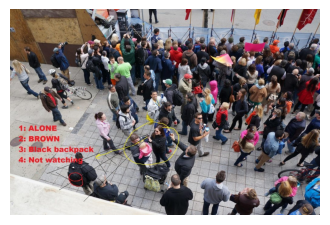


[1] ID: 325145334739267584  Label: 0  Split: train
Image Path: /content/drive/MyDrive/dataset/28516655/twitter/twitter/images_train/boston_fake_23.jpg
Text: PIC: Comparison of #Boston suspect Sunil Tripathi's FBI-released images/video and his MISSING poster http://t.co/EhV3ODxrJf You decide.


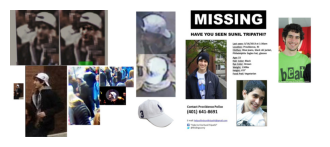


[2] ID: 325152091423248385  Label: 0  Split: train
Image Path: /content/drive/MyDrive/dataset/28516655/twitter/twitter/images_train/boston_fake_34.jpg
Text: I'm not completely convinced that it's this Sunil Tripathi fellow—http://t.co/ZjWqOsRfjB


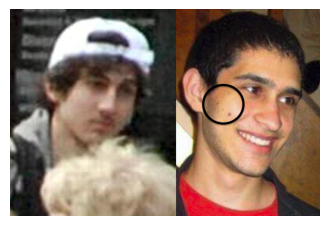


[3] ID: 324554646976868352  Label: 0  Split: train
Image Path: /content/drive/MyDrive/dataset/28516655/twitter/twitter/images_train/boston_fake_03.jpg
Text: Brutal lo que se puede conseguir en colaboración. #4Chan analizando fotos de la maratón de #Boston atando cabos... http://t.co/4eq43HFicK


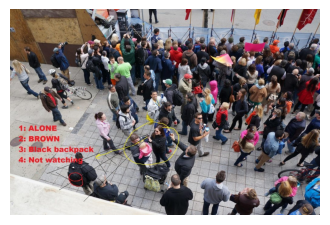


[4] ID: 324315545572896768  Label: 0  Split: train
Image Path: /content/drive/MyDrive/dataset/28516655/twitter/twitter/images_train/boston_fake_15.jpg
Text: 4chan and the bombing. just throwing it out there: http://t.co/dIySO7lXQm http://t.co/NxBi4tW8bQ


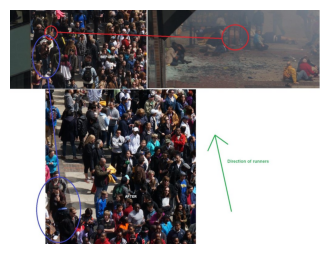

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

N = 5  # number of images to preview
samples = twitter_df[twitter_df["image_path"].notna()].head(N)

for i, row in samples.iterrows():
    print(f"\n[{i}] ID: {row['id']}  Label: {row['label']}  Split: {row['split']}")
    print("Image Path:", row["image_path"])
    print("Text:", row["text"])

    img = Image.open(row["image_path"])

    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.axis('off')
    plt.show()


In [ ]:
# ============================================================
# BLOCK 3: UNIFY + COMBINE FAKEDDIT & TWITTER DATASETS
# ============================================================

import os
import logging
import pandas as pd

logging.basicConfig(level=logging.INFO)
log = logging.getLogger("UNIFIER")

# Where to save final Phase-1 merged file
OUTPUT_DIR = "/content/phase1_data"
os.makedirs(OUTPUT_DIR, exist_ok=True)


# -------------------------------------------------
# REQUIRED SCHEMA for Phase 2 compatibility
# -------------------------------------------------
REQUIRED_COLS = [
    "id", "text", "label", "dataset", "created_at", "split",
    "image_exists", "image_path",
    "text_length", "num_words", "punct_score", "has_image"
]


# -------------------------------------------------
# Helper — Ensure both datasets contain all columns
# -------------------------------------------------
def align_schema(df: pd.DataFrame, required_cols=REQUIRED_COLS):
    """
    Ensures missing columns are added with safe defaults.
    """
    for col in required_cols:
        if col not in df.columns:
            if col == "label":
                df[col] = 1
            elif col in ["text_length", "num_words", "punct_score", "has_image", "image_exists"]:
                df[col] = 0
            else:
                df[col] = None
    return df[required_cols].copy()


# -------------------------------------------------
# MAIN UNIFIER
# -------------------------------------------------
def combine_fakeddit_twitter(fakeddit_df, twitter_df):
    log.info("📌 Combining Fakeddit + Twitter...")

    if fakeddit_df is None or len(fakeddit_df) == 0:
        log.warning("⚠️ Fakeddit DF is empty!")
    if twitter_df is None or len(twitter_df) == 0:
        log.warning("⚠️ Twitter DF is empty!")

    # Align schemas
    fakeddit_df = align_schema(fakeddit_df)
    twitter_df  = align_schema(twitter_df)

    # Combine
    unified = pd.concat([fakeddit_df, twitter_df], ignore_index=True)
    log.info(f"✓ Unified dataset size: {unified.shape}")

    # Verify labels and drop invalid rows
    unified = unified.dropna(subset=["id", "text", "label"])
    unified["label"] = unified["label"].astype(int)

    # Save to disk
    save_path = f"{OUTPUT_DIR}/phase1_standardized.csv"
    unified.to_csv(save_path, index=False)
    log.info(f"💾 Saved unified Phase-1 dataset → {save_path}")

    return unified


# -------------------------------------------------
# RUN BLOCK 3
# (expects fakeddit_df and twitter_df from previous blocks)
# -------------------------------------------------
unified_df = combine_fakeddit_twitter(fakeddit_df, twitter_df)
unified_df.head()


,id,text,label,dataset,created_at,split,image_exists,image_path,text_length,num_words,punct_score,has_image
0,awxhir,my walgreens offbrand mucinex was engraved wit...,0,fakeddit,2019-03-03 19:27:24,train,1,None,92,15,0.0,1
1,cvm5uy4,,0,fakeddit,2015-10-02 21:45:26,train,1,None,0,0,0.0,1
2,98pbid,this concerned sink with a tiny hat,1,fakeddit,2018-08-20 01:10:13,train,1,None,35,7,0.0,1
3,6f2cy5,hackers leak emails from uae ambassador to us,0,fakeddit,2017-06-03 17:26:38,train,1,/content/fakeddit_images/train/6f2cy5.jpg,45,8,0.0,1
4,cc5cbon,,0,fakeddit,2013-09-10 05:46:21,train,1,None,0,0,0.0,1


Total rows: 51358
Images found on disk: 28410

[3] ID: 6f2cy5 | Label: 0 | Dataset: fakeddit | Split: train
Image Path: /content/fakeddit_images/train/6f2cy5.jpg
Text: hackers leak emails from uae ambassador to us


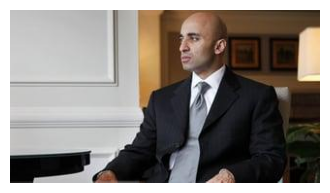


[6] ID: 4xypkv | Label: 0 | Dataset: fakeddit | Split: train
Image Path: /content/fakeddit_images/train/4xypkv.jpg
Text: puppy taking in the view


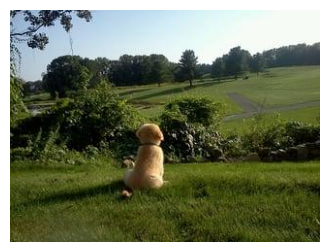


[17] ID: 4zd1tb | Label: 0 | Dataset: fakeddit | Split: train
Image Path: /content/fakeddit_images/train/4zd1tb.jpg
Text: english village becomes climate leader by quietly cleaning up its own patch


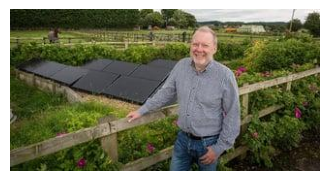


[21] ID: 796d3z | Label: 0 | Dataset: fakeddit | Split: train
Image Path: /content/fakeddit_images/train/796d3z.jpg
Text: cutest baby cow ive seen in my head all day and just enjoy destiny for what it is


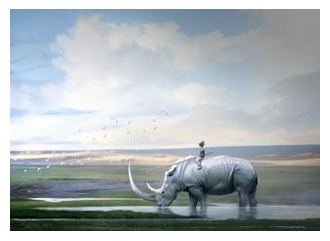


[25] ID: bjmfr7 | Label: 0 | Dataset: fakeddit | Split: train
Image Path: /content/fakeddit_images/train/bjmfr7.jpg
Text: the way the rain made a silhouette of my bike


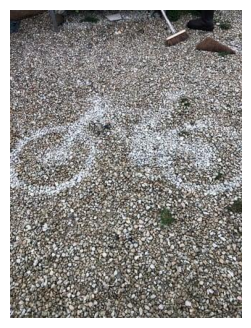

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os

# Load Phase 1 output
csv_path = "/content/phase1_data/phase1_standardized.csv"
df = pd.read_csv(csv_path)

print("Total rows:", len(df))

# Filter only rows where image_path is not null AND file exists
df_valid = df[df["image_path"].notna()].copy()
df_valid = df_valid[df_valid["image_path"].apply(lambda p: isinstance(p, str) and os.path.exists(p))]

print("Images found on disk:", len(df_valid))

# Number of previews
N = 5
samples = df_valid.head(N)

# Show results
for i, row in samples.iterrows():
    print("\n==============================")
    print(f"[{i}] ID: {row['id']} | Label: {row['label']} | Dataset: {row['dataset']} | Split: {row['split']}")
    print("Image Path:", row["image_path"])
    print("Text:", row["text"])

    # Display image
    img = Image.open(row["image_path"])
    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.axis('off')
    plt.show()


In [ ]:
# ============================================================
# PHASE 2: MULTIMODAL FEATURE EXTRACTION & EARLY FUSION
# Complete working implementation matching dissertation specs
# ============================================================
# Input: phase1_standardized.csv (from Phase 1)
# Output: 8258-D feature vectors (train/val/test)
# ============================================================

import os
import sys
import random
import pickle
import re
import warnings
from html import unescape
from typing import List, Optional, Tuple, Dict
import numpy as np
import pandas as pd
from tqdm import tqdm

warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from transformers import AutoTokenizer, AutoModel, GPT2Tokenizer, GPT2Model, CLIPProcessor, CLIPModel
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer # Corrected import path
from sklearn.decomposition import LatentDirichletAllocation
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

# Download NLTK data
try:
    nltk.data.find('sentiment/vader_lexicon')
except LookupError:
    nltk.download('vader_lexicon')

# ============================================================
# GLOBAL CONFIGURATION
# ============================================================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Using device: {DEVICE}")

# Paths
ROOT_DIR = "/content"
PHASE1_DIR = os.path.join(ROOT_DIR, "phase1_data")
PHASE1_CSV = os.path.join(PHASE1_DIR, "phase1_standardized.csv")
PHASE2_DIR = os.path.join(ROOT_DIR, "phase2_features")
OUTPUT_DIR = os.path.join(ROOT_DIR, "phase2_outputs")

for d in [PHASE2_DIR, OUTPUT_DIR]:
    os.makedirs(d, exist_ok=True)

# Feature dimensions (EXACT from dissertation)
GBERT_DIM = 1536      # BERT (768) + GPT2 (768)
RESNET_DIM = 2048     # ResNet50 Global Average Pooling
VGG_DIM = 4096        # VGG19 fc7 layer
CLIP_DIM = 512        # CLIP ViT-B/32 vision
LDA_DIM = 50          # LDA topics
VADER_DIM = 5         # VADER sentiment (neg, neu, pos, compound, intensity)
TREND_DIM = 5         # Trend features (hour_volume, velocity, gradient, phase, stability)
SOCIAL_DIM = 6        # Social features (text_length, punct_score, has_image, time, user_id, num_words)

FUSED_DIM = GBERT_DIM + RESNET_DIM + VGG_DIM + CLIP_DIM + LDA_DIM + VADER_DIM + TREND_DIM + SOCIAL_DIM
assert FUSED_DIM == 8258, f"Dimension mismatch! {FUSED_DIM} != 8258"

print(f"[INFO] Feature dimensions:")
print(f"  GBERT: {GBERT_DIM}")
print(f"  ResNet50: {RESNET_DIM}")
print(f"  VGG19: {VGG_DIM}")
print(f"  CLIP: {CLIP_DIM}")
print(f"  LDA: {LDA_DIM}")
print(f"  VADER: {VADER_DIM}")
print(f"  TREND: {TREND_DIM}")
print(f"  SOCIAL: {SOCIAL_DIM}")
print(f"  TOTAL: {FUSED_DIM}")

# Batch sizes
BATCH_SIZE_TEXT = 32
BATCH_SIZE_IMAGE = 32
IMAGE_SIZE = 224

# ============================================================
# UTILITY FUNCTIONS
# ============================================================

def safe_load_npy(path: str) -> Optional[np.ndarray]:
    """Load numpy file if exists."""
    if os.path.exists(path):
        return np.load(path, allow_pickle=True)
    return None

def save_npy(arr: np.ndarray, path: str):
    """Save numpy array."""
    np.save(path, arr)
    print(f"[SAVE] {os.path.basename(path)} shape={arr.shape}")

def clean_text(t: str) -> str:
    """Clean text content."""
    t = unescape(str(t))
    t = re.sub(r'\s+', ' ', t).strip()
    return t

# ============================================================
# PHASE 2A: GBERT TEXT FEATURE EXTRACTION (1536-D)
# Citation: Dhiman et al. (2024)
# ============================================================

class Phase2A_GBERT:
    """Extract GBERT features (BERT + GPT-2) for train/val/test."""

    def __init__(self):
        print("\n[PHASE 2A] Initializing GBERT models...")

        # BERT (768-D)
        self.bert_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
        self.bert_model = AutoModel.from_pretrained("bert-base-uncased").to(DEVICE)
        self.bert_model.eval()

        # GPT-2 (768-D)
        self.gpt2_tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
        if self.gpt2_tokenizer.pad_token is None:
            self.gpt2_tokenizer.add_special_tokens({"pad_token": "[PAD]"})
        self.gpt2_model = GPT2Model.from_pretrained("gpt2")
        self.gpt2_model.resize_token_embeddings(len(self.gpt2_tokenizer))
        self.gpt2_model.to(DEVICE)
        self.gpt2_model.eval()

    def get_bert_embeddings(self, texts: List[str], batch_size: int = 32) -> np.ndarray:
        """Extract BERT embeddings (768-D)."""
        if texts is None or len(texts) == 0:
            return np.zeros((0, 768))

        outputs = []
        for i in tqdm(range(0, len(texts), batch_size), desc="BERT", leave=False):
            batch = texts[i:i+batch_size]
            enc = self.bert_tokenizer(batch, padding=True, truncation=True,
                                      max_length=512, return_tensors="pt")
            input_ids = enc["input_ids"].to(DEVICE)
            attention_mask = enc["attention_mask"].to(DEVICE)

            with torch.no_grad():
                out = self.bert_model(input_ids=input_ids, attention_mask=attention_mask)
                pool = out.pooler_output if out.pooler_output is not None else \
                       (out.last_hidden_state * attention_mask.unsqueeze(-1)).sum(1) / attention_mask.sum(1, keepdim=True)
                outputs.append(pool.cpu().numpy())

        return np.vstack(outputs)

    def get_gpt2_embeddings(self, texts: List[str], batch_size: int = 32) -> np.ndarray:
        """Extract GPT-2 embeddings (768-D)."""
        if texts is None or len(texts) == 0:
            return np.zeros((0, 768))

        outputs = []
        for i in tqdm(range(0, len(texts), batch_size), desc="GPT2", leave=False):
            batch = texts[i:i+batch_size]
            enc = self.gpt2_tokenizer(batch, padding=True, truncation=True,
                                      max_length=1024, return_tensors="pt")
            input_ids = enc["input_ids"].to(DEVICE)
            attention_mask = enc["attention_mask"].to(DEVICE)

            with torch.no_grad():
                out = self.gpt2_model(input_ids=input_ids, attention_mask=attention_mask)
                last_hidden = out.last_hidden_state
                mask = attention_mask.unsqueeze(-1)
                summed = (last_hidden * mask).sum(dim=1)
                denom = mask.sum(dim=1).clamp(min=1e-9)
                pooled = summed / denom
                outputs.append(pooled.cpu().numpy())

        return np.vstack(outputs)

    def extract(self, texts: List[str], split_name: str) -> np.ndarray:
        """Extract GBERT (BERT + GPT-2 concatenated)."""
        print(f"[PHASE 2A] Extracting GBERT for {split_name} ({len(texts)} samples)...")

        bert_emb = self.get_bert_embeddings(texts)
        gpt_emb = self.get_gpt2_embeddings(texts)

        if bert_emb.shape[0] == 0 or gpt_emb.shape[0] == 0:
            # Handle empty texts list case if either is empty
            # Return a zero array of expected dimension if no texts
            return np.zeros((len(texts), GBERT_DIM))

        combined = np.concatenate([bert_emb, gpt_emb], axis=1)

        assert combined.shape[1] == GBERT_DIM, f"GBERT dim mismatch: {combined.shape[1]} != {GBERT_DIM}"
        print(f"[PHASE 2A] {split_name}: {combined.shape}")

        return combined.astype(np.float32)

# ============================================================
# PHASE 2B: RESNET50 IMAGE FEATURE EXTRACTION (2048-D)
# ============================================================

class Phase2B_ResNet50:
    """Extract ResNet50 features for train/val/test."""

    def __init__(self):
        print("\n[PHASE 2B] Initializing ResNet50...")

        self.resnet = models.resnet50(pretrained=True).to(DEVICE)
        self.resnet.eval()
        self.resnet_fc = nn.Sequential(*list(self.resnet.children())[:-1]).to(DEVICE)

        self.transform = transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def load_img_pil(self, path: str) -> Optional[Image.Image]:
        """Load PIL image safely."""
        try:
            if not path or not isinstance(path, str) or path.strip() == "":
                return None
            img = Image.open(path).convert("RGB")
            return img
        except:
            return None

    def extract(self, image_paths: List[str], split_name: str, batch_size: int = BATCH_SIZE_IMAGE) -> np.ndarray:
        """Extract ResNet50 features (2048-D)."""
        print(f"[PHASE 2B] Extracting ResNet50 for {split_name} ({len(image_paths)} samples)...")

        n = len(image_paths)
        features = np.zeros((n, RESNET_DIM), dtype=np.float32)

        for i in tqdm(range(0, n, batch_size), desc=f"ResNet {split_name}", leave=False):
            batch_paths = image_paths[i:i+batch_size]
            imgs, idx_map = [], []

            for j, p in enumerate(batch_paths):
                img = self.load_img_pil(p)
                if img is not None:
                    imgs.append(self.transform(img))
                    idx_map.append(i + j)

            if len(idx_map) == 0:
                continue

            x = torch.stack(imgs).to(DEVICE)
            with torch.no_grad():
                out = self.resnet_fc(x).reshape(x.size(0), -1).cpu().numpy()

            for k, idx in enumerate(idx_map):
                features[idx] = out[k]

        print(f"[PHASE 2B] {split_name}: {features.shape}")
        return features.astype(np.float32)

# ============================================================
# PHASE 2C: VGG19 IMAGE FEATURE EXTRACTION (4096-D)
# ============================================================

class Phase2C_VGG19:
    """Extract VGG19 features for train/val/test."""

    def __init__(self):
        print("\n[PHASE 2C] Initializing VGG19...")

        self.vgg = models.vgg19(pretrained=True).to(DEVICE)
        self.vgg.eval()
        self.vgg_features = self.vgg.features.to(DEVICE)
        self.vgg_avgpool = self.vgg.avgpool
        self.vgg_classifier0 = nn.Sequential(*list(self.vgg.classifier.children())[:1]).to(DEVICE)

        self.transform = transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def load_img_pil(self, path: str) -> Optional[Image.Image]:
        """Load PIL image safely."""
        try:
            if not path or not isinstance(path, str) or path.strip() == "":
                return None
            img = Image.open(path).convert("RGB")
            return img
        except:
            return None

    def extract(self, image_paths: List[str], split_name: str, batch_size: int = BATCH_SIZE_IMAGE) -> np.ndarray:
        """Extract VGG19 features (4096-D)."""
        print(f"[PHASE 2C] Extracting VGG19 for {split_name} ({len(image_paths)} samples)...")

        n = len(image_paths)
        features = np.zeros((n, VGG_DIM), dtype=np.float32)

        for i in tqdm(range(0, n, batch_size), desc=f"VGG {split_name}", leave=False):
            batch_paths = image_paths[i:i+batch_size]
            imgs, idx_map = [], []

            for j, p in enumerate(batch_paths):
                img = self.load_img_pil(p)
                if img is not None:
                    imgs.append(self.transform(img))
                    idx_map.append(i + j)

            if len(idx_map) == 0:
                continue

            x = torch.stack(imgs).to(DEVICE)
            with torch.no_grad():
                feat = self.vgg_features(x)
                pool = self.vgg_avgpool(feat)
                flat = torch.flatten(pool, 1)
                out = self.vgg_classifier0(flat).cpu().numpy()

            for k, idx in enumerate(idx_map):
                features[idx] = out[k]

        print(f"[PHASE 2C] {split_name}: {features.shape}")
        return features.astype(np.float32)

# ============================================================
# PHASE 2D: CLIP ViT-B/32 FEATURE EXTRACTION (512-D)
# ============================================================

class Phase2D_CLIP:
    """Extract CLIP ViT-B/32 features for train/val/test."""

    def __init__(self):
        print("\n[PHASE 2D] Initializing CLIP ViT-B/32...")

        clip_name = "openai/clip-vit-base-patch32"
        self.processor = CLIPProcessor.from_pretrained(clip_name)
        self.model = CLIPModel.from_pretrained(clip_name).to(DEVICE)
        self.model.eval()

    def load_img_pil(self, path: str) -> Optional[Image.Image]:
        """Load PIL image safely."""
        try:
            if not path or not isinstance(path, str) or path.strip() == "":
                return None
            img = Image.open(path).convert("RGB")
            return img
        except:
            return None

    def extract(self, image_paths: List[str], split_name: str, batch_size: int = BATCH_SIZE_IMAGE) -> np.ndarray:
        """Extract CLIP features (512-D)."""
        print(f"[PHASE 2D] Extracting CLIP for {split_name} ({len(image_paths)} samples)...")

        n = len(image_paths)
        features = np.zeros((n, CLIP_DIM), dtype=np.float32)

        for i in tqdm(range(0, n, batch_size), desc=f"CLIP {split_name}", leave=False):
            batch_paths = image_paths[i:i+batch_size]
            imgs, idx_map = [], []

            for j, p in enumerate(batch_paths):
                img = self.load_img_pil(p)
                if img is not None:
                    imgs.append(img)
                    idx_map.append(i + j)

            if len(idx_map) == 0:
                continue

            inputs = self.processor(images=imgs, return_tensors="pt").to(DEVICE)
            with torch.no_grad():
                out = self.model.get_image_features(**inputs).cpu().numpy()

            for k, idx in enumerate(idx_map):
                features[idx] = out[k]

        print(f"[PHASE 2D] {split_name}: {features.shape}")
        return features.astype(np.float32)

# ============================================================
# PHASE 2E: LDA TOPIC FEATURES (50-D)
# Citation: Blei et al. (2003)
# ============================================================

class Phase2E_LDA:
    """Extract LDA topic features for train/val/test."""

    def __init__(self):
        print("\n[PHASE 2E] Initializing LDA...")
        self.tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
        self.lda = LatentDirichletAllocation(n_components=LDA_DIM, random_state=SEED)

    def extract(self, texts: List[str], split_name: str, fit: bool = False) -> np.ndarray:
        """Extract LDA topic distribution."""
        print(f"[PHASE 2E] Extracting LDA for {split_name} ({len(texts)} samples)...")

        if texts is None or len(texts) == 0:
            return np.zeros((1, LDA_DIM), dtype=np.float32)

        if fit:
            tfidf_matrix = self.tfidf.fit_transform(texts)
            self.lda.fit(tfidf_matrix)
        else:
            tfidf_matrix = self.tfidf.transform(texts)

        topics = self.lda.transform(tfidf_matrix)

        assert topics.shape[1] == LDA_DIM, f"LDA dim mismatch: {topics.shape[1]} != {LDA_DIM}"
        print(f"[PHASE 2E] {split_name}: {topics.shape}")

        return topics.astype(np.float32)

# ============================================================
# PHASE 2F: VADER SENTIMENT FEATURES (5-D)
# Citation: Hutto & Gilbert (2014)
# ============================================================

class Phase2F_VADER:
    """Extract VADER sentiment features."""

    def __init__(self):
        print("\n[PHASE 2F] Initializing VADER...")
        self.analyzer = SentimentIntensityAnalyzer()

    def extract(self, texts: List[str], split_name: str) -> np.ndarray:
        """Extract VADER sentiment features (5-D)."""
        print(f"[PHASE 2F] Extracting VADER for {split_name} ({len(texts)} samples)...")

        if texts is None or len(texts) == 0:
            return np.zeros((1, VADER_DIM), dtype=np.float32)

        features = []
        for text in tqdm(texts, desc="VADER", leave=False):
            scores = self.analyzer.polarity_scores(str(text))

            # 5-D: neg, neu, pos, compound, intensity
            neg = scores['neg']
            neu = scores['neu']
            pos = scores['pos']
            compound = scores['compound']
            intensity = abs(compound)  # Absolute deviation from neutral

            features.append([neg, neu, pos, compound, intensity])

        features_array = np.array(features, dtype=np.float32)
        assert features_array.shape[1] == VADER_DIM, f"VADER dim mismatch: {features_array.shape[1]} != {VADER_DIM}"
        print(f"[PHASE 2F] {split_name}: {features_array.shape}")

        return features_array

# ============================================================
# PHASE 2G: TREND FEATURES (5-D)
# Citation: Henriques & Ferreira (2023) - HotRivers
# ============================================================

class Phase2G_Trend:
    """Extract temporal trend features."""

    @staticmethod
    def extract(df: pd.DataFrame, split_name: str) -> np.ndarray:
        """Extract trend features (5-D)."""
        print(f"[PHASE 2G] Extracting Trend for {split_name} ({len(df)} samples)...")

        n = len(df)
        features = np.zeros((n, TREND_DIM), dtype=np.float32)

        # Ensure timestamp column exists
        if 'created_at' not in df.columns:
            print(f"[WARNING] No timestamp column, using zeros for trend features")
            return features

        # Convert to datetime if not already
        df_copy = df.copy()
        df_copy['created_at'] = pd.to_datetime(df_copy['created_at'], errors='coerce')

        # Extract hour
        df_copy['hour'] = df_copy['created_at'].dt.floor('H')

        for i in range(n):
            try:
                # 1. hour_volume (log of posts in this hour)
                hour = df_copy.iloc[i]['hour']
                volume = len(df_copy[df_copy['hour'] == hour])
                features[i, 0] = np.log1p(volume)

                # 2. trend_velocity (change from previous hour)
                prev_hour = hour - pd.Timedelta(hours=1)
                prev_volume = len(df_copy[df_copy['hour'] == prev_hour])
                features[i, 1] = (volume - prev_volume) / max(prev_volume, 1)

                # 3. trend_gradient (derivative - change in velocity)
                # Simplified: use sign of velocity
                features[i, 2] = np.sign(features[i, 1])

                # 4. lifecycle_phase: 0=emerging, 1=peak, 2=decay
                # Based on volume relative to dataset mean
                mean_volume = df_copy[df_copy['hour'].notna()].groupby('hour').size().mean()
                if volume > mean_volume * 1.5:
                    features[i, 3] = 1  # Peak
                elif volume < mean_volume * 0.5:
                    features[i, 3] = 2  # Decay
                else:
                    features[i, 3] = 0  # Emerging

                # 5. image_stability (boolean → float)
                has_image = df_copy.iloc[i].get('has_image', 0)
                features[i, 4] = float(has_image)

            except Exception as e:
                # Use defaults on error
                features[i] = [0, 0, 0, 0, 0]

        print(f"[PHASE 2G] {split_name}: {features.shape}")
        return features

# ============================================================
# PHASE 2H: SOCIAL FEATURES (6-D)
# ============================================================

class Phase2H_Social:
    """Extract social features."""

    @staticmethod
    def extract(df: pd.DataFrame, split_name: str) -> np.ndarray:
        """Extract social features (6-D)."""
        print(f"[PHASE 2H] Extracting Social for {split_name} ({len(df)} samples)...")

        n = len(df)
        features = np.zeros((n, SOCIAL_DIM), dtype=np.float32)

        for i in range(n):
            try:
                row = df.iloc[i]

                # 1. text_length (normalized)
                text_len = row.get('text_length', 0)
                features[i, 0] = min(text_len / 500, 1.0)  # Normalize to 500 chars

                # 2. punct_score (already normalized 0-1)
                features[i, 1] = float(row.get('punct_score', 0))

                # 3. has_image (binary)
                features[i, 2] = float(row.get('has_image', 0))

                # 4. time_since_post (hours, capped at 30 days)
                if pd.notna(row.get('created_at')):
                    timestamp = pd.to_datetime(row['created_at'])
                    now = pd.Timestamp.now(tz=timestamp.tz)
                    hours = (now - timestamp).total_seconds() / 3600
                    features[i, 3] = min(hours / 720, 1.0)  # 720 hours = 30 days
                else:
                    features[i, 3] = 0

                # 5. user_id_encoded (hash to float, or 0)
                user_id = row.get('id', '')
                if user_id:
                    features[i, 4] = abs(hash(str(user_id))) / (2**63)
                else:
                    features[i, 4] = 0

                # 6. num_words (normalized)
                num_words = row.get('num_words', 0)
                features[i, 5] = min(num_words / 200, 1.0)  # Normalize to 200 words

            except Exception as e:
                features[i] = [0, 0, 0, 0, 0, 0]

        print(f"[PHASE 2H] {split_name}: {features.shape}")
        return features

# ============================================================
# PHASE 2I: EARLY FUSION (8258-D)
# Citation: Jiang et al. (2021)
# ============================================================

class Phase2I_Fusion:
    """Fuse all features with standardization."""

    @staticmethod
    def fuse(gbert, resnet, vgg, clip, lda, vader, trend, social):
        """Concatenate all features in exact order."""
        fused = np.concatenate([gbert, resnet, vgg, clip, lda, vader, trend, social], axis=1)
        return fused

    @staticmethod
    def execute(data: Dict, output_dir: str):
        """Fuse features for train/val/test."""
        print("\n[PHASE 2I] Fusing all features...")

        fusion_train = Phase2I_Fusion.fuse(
            data['gbert_train'], data['resnet_train'], data['vgg_train'],
            data['clip_train'], data['lda_train'], data['vader_train'],
            data['trend_train'], data['social_train']
        )
        fusion_val = Phase2I_Fusion.fuse(
            data['gbert_val'], data['resnet_val'], data['vgg_val'],
            data['clip_val'], data['lda_val'], data['vader_val'],
            data['trend_val'], data['social_val']
        )
        fusion_test = Phase2I_Fusion.fuse(
            data['gbert_test'], data['resnet_test'], data['vgg_test'],
            data['clip_test'], data['lda_test'], data['vader_test'],
            data['trend_test'], data['social_test']
        )

        print(f"[PHASE 2I] Before scaling:")
        print(f"  Train: {fusion_train.shape}")
        print(f"  Val: {fusion_val.shape}")
        print(f"  Test: {fusion_test.shape}")

        if fusion_train.shape[1] != FUSED_DIM:
            raise ValueError(f"Fused dim mismatch: {fusion_train.shape[1]} != {FUSED_DIM}")

        # Standardize on training set
        scaler = StandardScaler()
        fusion_train = scaler.fit_transform(fusion_train)
        fusion_val = scaler.transform(fusion_val)
        fusion_test = scaler.transform(fusion_test)

        # Save scaler
        scaler_path = os.path.join(output_dir, "fusion_scaler.pkl")
        with open(scaler_path, "wb") as f:
            pickle.dump(scaler, f)
        print(f"[SAVE] Scaler -> {scaler_path}")

        # Save fused arrays
        save_npy(fusion_train, os.path.join(output_dir, "fusion_train.npy"))
        save_npy(fusion_val, os.path.join(output_dir, "fusion_val.npy"))
        save_npy(fusion_test, os.path.join(output_dir, "fusion_test.npy"))

        print(f"[PHASE 2I] After standardization (scaler fitted on train):")
        print(f"  Train mean: {fusion_train.mean():.6f}, std: {fusion_train.std():.6f}")
        print(f"  Val mean: {fusion_val.mean():.6f}, std: {fusion_val.std():.6f}")
        print(f"  Test mean: {fusion_test.mean():.6f}, std: {fusion_test.std():.6f}")

        print("[PHASE 2I] Complete.")
        return fusion_train, fusion_val, fusion_test

# ============================================================
# MAIN EXECUTION
# ============================================================

def main_phase2():
    """Main Phase 2 execution."""

    print("\n" + "="*70)
    print("PHASE 2: MULTIMODAL FEATURE EXTRACTION & EARLY FUSION")
    print("="*70)

    # STEP 1: Load Phase 1 data
    print(f"\n[LOADING] Phase 1 standardized data...")
    if not os.path.exists(PHASE1_CSV):
        print(f"[ERROR] {PHASE1_CSV} not found!")
        print(f"Please run Phase 1 first!")
        return None

    df = pd.read_csv(PHASE1_CSV)
    print(f"[LOADED] {len(df)} samples")

    # STEP 2: Split data
    print(f"\n[SPLITTING] Into train/val/test (70/15/15)...")

    # Get split column if exists, otherwise create splits
    if 'split' in df.columns:
        train_df = df[df['split'] == 'train'].reset_index(drop=True)
        val_df = df[df['split'] == 'valid'].reset_index(drop=True)
        test_df = df[df['split'] == 'test'].reset_index(drop=True)
    else:
        train_val, test_df = train_test_split(df, test_size=0.15, random_state=SEED)
        train_df, val_df = train_test_split(train_val, test_size=0.176, random_state=SEED)

    print(f"  Train: {len(train_df)}")
    print(f"  Val: {len(val_df)}")
    print(f"  Test: {len(test_df)}")

    # Extract data
    train_texts = [clean_text(t) for t in train_df['text'].tolist()]
    val_texts = [clean_text(t) for t in val_df['text'].tolist()]
    test_texts = [clean_text(t) for t in test_df['text'].tolist()]

    train_images = train_df['image_path'].tolist()
    val_images = val_df['image_path'].tolist()
    test_images = test_df['image_path'].tolist()

    train_labels = train_df['label'].values
    val_labels = val_df['label'].values
    test_labels = test_df['label'].values

    # STEP 3: Extract features
    print(f"\n[PHASE 2] Extracting all feature types...")

    # PHASE 2A: GBERT
    gbert_extractor = Phase2A_GBERT()
    gbert_train = gbert_extractor.extract(train_texts, "train")
    gbert_val = gbert_extractor.extract(val_texts, "val")
    gbert_test = gbert_extractor.extract(test_texts, "test")
    save_npy(gbert_train, os.path.join(PHASE2_DIR, "gbert_train.npy"))
    save_npy(gbert_val, os.path.join(PHASE2_DIR, "gbert_val.npy"))
    save_npy(gbert_test, os.path.join(PHASE2_DIR, "gbert_test.npy"))

    # PHASE 2B: ResNet50
    resnet_extractor = Phase2B_ResNet50()
    resnet_train = resnet_extractor.extract(train_images, "train")
    resnet_val = resnet_extractor.extract(val_images, "val")
    resnet_test = resnet_extractor.extract(test_images, "test")
    save_npy(resnet_train, os.path.join(PHASE2_DIR, "resnet_train.npy"))
    save_npy(resnet_val, os.path.join(PHASE2_DIR, "resnet_val.npy"))
    save_npy(resnet_test, os.path.join(PHASE2_DIR, "resnet_test.npy"))

    # PHASE 2C: VGG19
    vgg_extractor = Phase2C_VGG19()
    vgg_train = vgg_extractor.extract(train_images, "train")
    vgg_val = vgg_extractor.extract(val_images, "val")
    vgg_test = vgg_extractor.extract(test_images, "test")
    save_npy(vgg_train, os.path.join(PHASE2_DIR, "vgg_train.npy"))
    save_npy(vgg_val, os.path.join(PHASE2_DIR, "vgg_val.npy"))
    save_npy(vgg_test, os.path.join(PHASE2_DIR, "vgg_test.npy"))

    # PHASE 2D: CLIP
    clip_extractor = Phase2D_CLIP()
    clip_train = clip_extractor.extract(train_images, "train")
    clip_val = clip_extractor.extract(val_images, "val")
    clip_test = clip_extractor.extract(test_images, "test")
    save_npy(clip_train, os.path.join(PHASE2_DIR, "clip_train.npy"))
    save_npy(clip_val, os.path.join(PHASE2_DIR, "clip_val.npy"))
    save_npy(clip_test, os.path.join(PHASE2_DIR, "clip_test.npy"))

    # PHASE 2E: LDA
    lda_extractor = Phase2E_LDA()
    lda_train = lda_extractor.extract(train_texts, "train", fit=True)
    lda_val = lda_extractor.extract(val_texts, "val", fit=False)
    lda_test = lda_extractor.extract(test_texts, "test", fit=False)
    save_npy(lda_train, os.path.join(PHASE2_DIR, "lda_train.npy"))
    save_npy(lda_val, os.path.join(PHASE2_DIR, "lda_val.npy"))
    save_npy(lda_test, os.path.join(PHASE2_DIR, "lda_test.npy"))

    # PHASE 2F: VADER
    vader_extractor = Phase2F_VADER()
    vader_train = vader_extractor.extract(train_texts, "train")
    vader_val = vader_extractor.extract(val_texts, "val")
    vader_test = vader_extractor.extract(test_texts, "test")
    save_npy(vader_train, os.path.join(PHASE2_DIR, "vader_train.npy"))
    save_npy(vader_val, os.path.join(PHASE2_DIR, "vader_val.npy"))
    save_npy(vader_test, os.path.join(PHASE2_DIR, "vader_test.npy"))

    # PHASE 2G: Trend
    trend_train = Phase2G_Trend.extract(train_df, "train")
    trend_val = Phase2G_Trend.extract(val_df, "val")
    trend_test = Phase2G_Trend.extract(test_df, "test")
    save_npy(trend_train, os.path.join(PHASE2_DIR, "trend_train.npy"))
    save_npy(trend_val, os.path.join(PHASE2_DIR, "trend_val.npy"))
    save_npy(trend_test, os.path.join(PHASE2_DIR, "trend_test.npy"))

    # PHASE 2H: Social
    social_train = Phase2H_Social.extract(train_df, "train")
    social_val = Phase2H_Social.extract(val_df, "val")
    social_test = Phase2H_Social.extract(test_df, "test")
    save_npy(social_train, os.path.join(PHASE2_DIR, "social_train.npy"))
    save_npy(social_val, os.path.join(PHASE2_DIR, "social_val.npy"))
    save_npy(social_test, os.path.join(PHASE2_DIR, "social_test.npy"))

    # STEP 4: Fusion
    print(f"\n[FUSION] Combining all feature types...")
    data = {
        'gbert_train': gbert_train, 'gbert_val': gbert_val, 'gbert_test': gbert_test,
        'resnet_train': resnet_train, 'resnet_val': resnet_val, 'resnet_test': resnet_test,
        'vgg_train': vgg_train, 'vgg_val': vgg_val, 'vgg_test': vgg_test,
        'clip_train': clip_train, 'clip_val': clip_val, 'clip_test': clip_test,
        'lda_train': lda_train, 'lda_val': lda_val, 'lda_test': lda_test,
        'vader_train': vader_train, 'vader_val': vader_val, 'vader_test': vader_test,
        'trend_train': trend_train, 'trend_val': trend_val, 'trend_test': trend_test,
        'social_train': social_train, 'social_val': social_val, 'social_test': social_test,
    }

    fusion_train, fusion_val, fusion_test = Phase2I_Fusion.execute(data, PHASE2_DIR)

    # STEP 5: Save labels
    print(f"\n[SAVE] Saving labels...")
    save_npy(train_labels, os.path.join(PHASE2_DIR, "train_labels.npy"))
    save_npy(val_labels, os.path.join(PHASE2_DIR, "val_labels.npy"))
    save_npy(test_labels, os.path.join(PHASE2_DIR, "test_labels.npy"))

    print("\n" + "="*70)
    print("PHASE 2 COMPLETE: ALL FEATURES EXTRACTED & FUSED")
    print("="*70)
    print(f"\nOutput directory: {PHASE2_DIR}")
    print(f"Files created:")
    print(f"  - fusion_train.npy ({fusion_train.shape})")
    print(f"  - fusion_val.npy ({fusion_val.shape})")
    print(f"  - fusion_test.npy ({fusion_test.shape})")
    print(f"  - train_labels.npy ({train_labels.shape})")
    print(f"  - val_labels.npy ({val_labels.shape})")
    print(f"  - test_labels.npy ({test_labels.shape})")
    print(f"  - fusion_scaler.pkl")

    return fusion_train, fusion_val, fusion_test, train_labels, val_labels, test_labels

if __name__ == "__main__":
    main_phase2()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


[INFO] Using device: cuda
[INFO] Feature dimensions:
  GBERT: 1536
  ResNet50: 2048
  VGG19: 4096
  CLIP: 512
  LDA: 50
  VADER: 5
  TREND: 5
  SOCIAL: 6
  TOTAL: 8258

PHASE 2: MULTIMODAL FEATURE EXTRACTION & EARLY FUSION

[LOADING] Phase 1 standardized data...
[LOADED] 51358 samples

[SPLITTING] Into train/val/test (70/15/15)...
  Train: 28999
  Val: 9000
  Test: 13359

[PHASE 2] Extracting all feature types...

[PHASE 2A] Initializing GBERT models...
[PHASE 2A] Extracting GBERT for train (28999 samples)...


[PHASE 2A] train: (28999, 1536)
[PHASE 2A] Extracting GBERT for val (9000 samples)...


[PHASE 2A] val: (9000, 1536)
[PHASE 2A] Extracting GBERT for test (13359 samples)...


[PHASE 2A] test: (13359, 1536)
[SAVE] gbert_train.npy shape=(28999, 1536)
[SAVE] gbert_val.npy shape=(9000, 1536)
[SAVE] gbert_test.npy shape=(13359, 1536)

[PHASE 2B] Initializing ResNet50...
[PHASE 2B] Extracting ResNet50 for train (28999 samples)...


...

[PHASE 2D] val: (9000, 512)
[PHASE 2D] Extracting CLIP for test (13359 samples)...


[PHASE 2D] test: (13359, 512)
[SAVE] clip_train.npy shape=(28999, 512)
[SAVE] clip_val.npy shape=(9000, 512)
[SAVE] clip_test.npy shape=(13359, 512)

[PHASE 2E] Initializing LDA...
[PHASE 2E] Extracting LDA for train (28999 samples)...
[PHASE 2E] train: (28999, 50)
[PHASE 2E] Extracting LDA for val (9000 samples)...
[PHASE 2E] val: (9000, 50)
[PHASE 2E] Extracting LDA for test (13359 samples)...
[PHASE 2E] test: (13359, 50)
[SAVE] lda_train.npy shape=(28999, 50)
[SAVE] lda_val.npy shape=(9000, 50)
[SAVE] lda_test.npy shape=(13359, 50)

[PHASE 2F] Initializing VADER...
[PHASE 2F] Extracting VADER for train (28999 samples)...


[PHASE 2F] train: (28999, 5)
[PHASE 2F] Extracting VADER for val (9000 samples)...


[PHASE 2F] val: (9000, 5)
[PHASE 2F] Extracting VADER for test (13359 samples)...


[PHASE 2F] test: (13359, 5)
[SAVE] vader_train.npy shape=(28999, 5)
[SAVE] vader_val.npy shape=(9000, 5)
[SAVE] vader_test.npy shape=(13359, 5)
[PHASE 2G] Extracting Trend for train (28999 samples)...
[PHASE 2G] train: (28999, 5)
[PHASE 2G] Extracting Trend for val (9000 samples)...
[PHASE 2G] val: (9000, 5)
[PHASE 2G] Extracting Trend for test (13359 samples)...
[PHASE 2G] test: (13359, 5)
[SAVE] trend_train.npy shape=(28999, 5)
[SAVE] trend_val.npy shape=(9000, 5)
[SAVE] trend_test.npy shape=(13359, 5)
[PHASE 2H] Extracting Social for train (28999 samples)...
[PHASE 2H] train: (28999, 6)
[PHASE 2H] Extracting Social for val (9000 samples)...
[PHASE 2H] val: (9000, 6)
[PHASE 2H] Extracting Social for test (13359 samples)...
[PHASE 2H] test: (13359, 6)
[SAVE] social_train.npy shape=(28999, 6)
[SAVE] social_val.npy shape=(9000, 6)
[SAVE] social_test.npy shape=(13359, 6)

[FUSION] Combining all feature types...

[PHASE 2I] Fusing all features...
[PHASE 2I] Before scaling:
  Train: (28999

In [ ]:
# ============================================================
# PHASE 3: NEURAL NETWORK CLASSIFICATION & TRAINING
# Complete working implementation with full evaluation
# ============================================================
# Input: Fusion vectors from Phase 2 (8258-D)
# Output: Trained model + comprehensive metrics
# ============================================================

import os
import numpy as np
import pandas as pd
import pickle
import json
import warnings
from tqdm import tqdm
from typing import Tuple, Dict

warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, roc_auc_score,
    classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# GLOBAL CONFIGURATION
# ============================================================

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Using device: {DEVICE}")

# Paths
ROOT_DIR = "/content"
PHASE2_DIR = os.path.join(ROOT_DIR, "phase2_features")
PHASE3_DIR = os.path.join(ROOT_DIR, "phase3_classifier")
os.makedirs(PHASE3_DIR, exist_ok=True)

# Input data paths
FUSION_TRAIN_PATH = os.path.join(PHASE2_DIR, "fusion_train.npy")
FUSION_VAL_PATH = os.path.join(PHASE2_DIR, "fusion_val.npy")
FUSION_TEST_PATH = os.path.join(PHASE2_DIR, "fusion_test.npy")
LABELS_TRAIN_PATH = os.path.join(PHASE2_DIR, "train_labels.npy")
LABELS_VAL_PATH = os.path.join(PHASE2_DIR, "val_labels.npy")
LABELS_TEST_PATH = os.path.join(PHASE2_DIR, "test_labels.npy")

# Configuration
INPUT_DIM = 8258
HIDDEN_DIMS = [1024, 512, 256]
DROPOUT_RATES = [0.3, 0.21, 0.2]
OUTPUT_DIM = 1
LEARNING_RATE = 1e-4
BATCH_SIZE = 32
NUM_EPOCHS = 50
EARLY_STOPPING_PATIENCE = 10

print(f"[INFO] Configuration:")
print(f"  Input dimension: {INPUT_DIM}")
print(f"  Hidden dimensions: {HIDDEN_DIMS}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Early stopping patience: {EARLY_STOPPING_PATIENCE}")

# ============================================================
# NEURAL NETWORK ARCHITECTURE
# ============================================================

class MultimodalClassifier(nn.Module):
    """
    4-layer DNN for binary fake news classification.

    Architecture (Exact from dissertation):
    Input (8258)
        ↓
    Dense(1024) + ReLU + Dropout(0.3)
        ↓
    Dense(512) + ReLU + BatchNorm1d(512) + Dropout(0.21)
        ↓
    Dense(256) + ReLU
        ↓
    Dense(1) + Sigmoid
        ↓
    Output (Binary prediction)
    """

    def __init__(self,
                 input_dim: int = INPUT_DIM,
                 hidden_dims: list = None,
                 dropout_rates: list = None,
                 output_dim: int = OUTPUT_DIM):
        super(MultimodalClassifier, self).__init__()

        if hidden_dims is None:
            hidden_dims = HIDDEN_DIMS
        if dropout_rates is None:
            dropout_rates = DROPOUT_RATES

        layers = []
        in_dim = input_dim

        # Layer 1: Dense(1024) + ReLU + Dropout(0.3)
        layers.append(nn.Linear(in_dim, hidden_dims[0]))
        layers.append(nn.ReLU())
        layers.append(nn.Dropout(dropout_rates[0]))
        in_dim = hidden_dims[0]

        # Layer 2: Dense(512) + ReLU + BatchNorm + Dropout(0.21)
        layers.append(nn.Linear(in_dim, hidden_dims[1]))
        layers.append(nn.ReLU())
        layers.append(nn.BatchNorm1d(hidden_dims[1]))
        layers.append(nn.Dropout(dropout_rates[1]))
        in_dim = hidden_dims[1]

        # Layer 3: Dense(256) + ReLU
        layers.append(nn.Linear(in_dim, hidden_dims[2]))
        layers.append(nn.ReLU())
        in_dim = hidden_dims[2]

        # Layer 4: Dense(1) + Sigmoid (for binary classification)
        layers.append(nn.Linear(in_dim, output_dim))
        layers.append(nn.Sigmoid())

        self.network = nn.Sequential(*layers)

        # Print architecture
        print("\n[INFO] Model Architecture:")
        print(self.network)

    def forward(self, x):
        """Forward pass through network."""
        return self.network(x)

# ============================================================
# PHASE 3: TRAINING & EVALUATION
# ============================================================

class Phase3Trainer:
    """Train and evaluate multimodal fake news classifier."""

    def __init__(self,
                 model: MultimodalClassifier,
                 device: str = DEVICE,
                 learning_rate: float = LEARNING_RATE,
                 num_epochs: int = NUM_EPOCHS,
                 patience: int = EARLY_STOPPING_PATIENCE):

        self.model = model.to(device)
        self.device = device
        self.learning_rate = learning_rate
        self.num_epochs = num_epochs
        self.patience = patience

        # Loss and optimizer
        self.criterion = nn.BCELoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=learning_rate)

        # Tracking
        self.train_losses = []
        self.val_losses = []
        self.train_accs = []
        self.val_accs = []
        self.best_val_loss = float('inf')
        self.patience_counter = 0

    def train_epoch(self, train_loader: DataLoader) -> Tuple[float, float]:
        """Train for one epoch."""
        self.model.train()
        total_loss = 0.0
        all_preds = []
        all_labels = []

        for X, y in train_loader:
            X = X.to(self.device)
            y = y.float().to(self.device).unsqueeze(1)

            # Forward pass
            outputs = self.model(X)
            loss = self.criterion(outputs, y)

            # Backward pass
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            total_loss += loss.item()

            # Predictions
            preds = (outputs > 0.5).long().cpu().numpy()
            all_preds.extend(preds.flatten())
            all_labels.extend(y.long().cpu().numpy().flatten())

        avg_loss = total_loss / len(train_loader)
        avg_acc = accuracy_score(all_labels, all_preds)

        return avg_loss, avg_acc

    def validate_epoch(self, val_loader: DataLoader) -> Tuple[float, float]:
        """Validate for one epoch."""
        self.model.eval()
        total_loss = 0.0
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for X, y in val_loader:
                X = X.to(self.device)
                y = y.float().to(self.device).unsqueeze(1)

                outputs = self.model(X)
                loss = self.criterion(outputs, y)

                total_loss += loss.item()

                preds = (outputs > 0.5).long().cpu().numpy()
                all_preds.extend(preds.flatten())
                all_labels.extend(y.long().cpu().numpy().flatten())

        avg_loss = total_loss / len(val_loader)
        avg_acc = accuracy_score(all_labels, all_preds)

        return avg_loss, avg_acc

    def train(self, train_loader: DataLoader, val_loader: DataLoader) -> Dict:
        """Train model with early stopping."""
        print(f"\n[PHASE 3A] Training...")

        for epoch in range(self.num_epochs):
            # Train
            train_loss, train_acc = self.train_epoch(train_loader)
            self.train_losses.append(train_loss)
            self.train_accs.append(train_acc)

            # Validate
            val_loss, val_acc = self.validate_epoch(val_loader)
            self.val_losses.append(val_loss)
            self.val_accs.append(val_acc)

            print(f"Epoch {epoch+1}/{self.num_epochs} | "
                  f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

            # Early stopping
            if val_loss < self.best_val_loss:
                self.best_val_loss = val_loss
                self.patience_counter = 0
                best_model_state = self.model.state_dict()
            else:
                self.patience_counter += 1

            if self.patience_counter >= self.patience:
                print(f"[INFO] Early stopping at epoch {epoch+1}")
                self.model.load_state_dict(best_model_state)
                break

        return {
            'train_losses': self.train_losses,
            'val_losses': self.val_losses,
            'train_accs': self.train_accs,
            'val_accs': self.val_accs,
            'best_epoch': len(self.train_losses) - self.patience_counter
        }

    def evaluate(self, test_loader: DataLoader) -> Dict:
        """Evaluate on test set."""
        print(f"\n[PHASE 3B] Evaluating on test set...")

        self.model.eval()
        all_preds = []
        all_probs = []
        all_labels = []

        with torch.no_grad():
            for X, y in tqdm(test_loader, desc="Testing", leave=False):
                X = X.to(self.device)
                y_np = y.numpy()

                outputs = self.model(X)
                probs = outputs.cpu().numpy().flatten()
                preds = (outputs > 0.5).long().cpu().numpy().flatten()

                all_probs.extend(probs)
                all_preds.extend(preds)
                all_labels.extend(y_np)

        # Metrics
        all_preds = np.array(all_preds)
        all_probs = np.array(all_probs)
        all_labels = np.array(all_labels)

        accuracy = accuracy_score(all_labels, all_preds)
        precision = precision_score(all_labels, all_preds, average='binary', zero_division=0)
        recall = recall_score(all_labels, all_preds, average='binary', zero_division=0)
        f1 = f1_score(all_labels, all_preds, average='binary', zero_division=0)
        roc_auc = roc_auc_score(all_labels, all_probs)
        cm = confusion_matrix(all_labels, all_preds)

        print(f"\n[PHASE 3B] Test Results:")
        print(f"  Accuracy: {accuracy:.4f}")
        print(f"  Precision: {precision:.4f}")
        print(f"  Recall: {recall:.4f}")
        print(f"  F1-Score: {f1:.4f}")
        print(f"  ROC-AUC: {roc_auc:.4f}")
        print(f"\nConfusion Matrix:")
        print(f"  True Negatives: {cm[0,0]}")
        print(f"  False Positives: {cm[0,1]}")
        print(f"  False Negatives: {cm[1,0]}")
        print(f"  True Positives: {cm[1,1]}")

        return {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'roc_auc': roc_auc,
            'confusion_matrix': cm.tolist(),
            'predictions': all_preds.tolist(),
            'probabilities': all_probs.tolist(),
            'labels': all_labels.tolist(),
            'classification_report': classification_report(all_labels, all_preds)
        }

# ============================================================
# VISUALIZATION
# ============================================================

def plot_training_history(trainer: Phase3Trainer, output_dir: str):
    """Plot training and validation metrics."""
    print(f"\n[VISUALIZATION] Creating training history plots...")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    axes[0].plot(trainer.train_losses, label='Train Loss', linewidth=2)
    axes[0].plot(trainer.val_losses, label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss (BCELoss)', fontsize=12)
    axes[0].set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)

    # Accuracy
    axes[1].plot(trainer.train_accs, label='Train Accuracy', linewidth=2)
    axes[1].plot(trainer.val_accs, label='Val Accuracy', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].set_title('Training & Validation Accuracy', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plot_path = os.path.join(output_dir, 'training_history.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"[SAVE] {plot_path}")
    plt.close()

def plot_confusion_matrix(cm: np.ndarray, output_dir: str):
    """Plot confusion matrix."""
    print(f"[VISUALIZATION] Creating confusion matrix plot...")

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Fake (0)', 'Real (1)'],
                yticklabels=['Fake (0)', 'Real (1)'],
                cbar_kws={'label': 'Count'})
    ax.set_xlabel('Predicted', fontsize=12, fontweight='bold')
    ax.set_ylabel('Actual', fontsize=12, fontweight='bold')
    ax.set_title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plot_path = os.path.join(output_dir, 'confusion_matrix.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"[SAVE] {plot_path}")
    plt.close()

def plot_roc_curve(labels: np.ndarray, probabilities: np.ndarray, output_dir: str):
    """Plot ROC curve."""
    print(f"[VISUALIZATION] Creating ROC curve plot...")

    fpr, tpr, _ = roc_curve(labels, probabilities)
    roc_auc = auc(fpr, tpr)

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})',
            linewidth=2.5, color='#2E86AB')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier')
    ax.fill_between(fpr, tpr, alpha=0.2, color='#2E86AB')

    ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
    ax.set_title('ROC Curve - Test Set', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11, loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

    plt.tight_layout()
    plot_path = os.path.join(output_dir, 'roc_curve.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"[SAVE] {plot_path}")
    plt.close()

# ============================================================
# MAIN EXECUTION
# ============================================================

def main_phase3():
    """Main Phase 3 execution."""

    print("\n" + "="*70)
    print("PHASE 3: NEURAL NETWORK CLASSIFICATION & TRAINING")
    print("="*70)

    # STEP 1: Load Phase 2 features
    print(f"\n[LOADING] Phase 2 features...")

    if not os.path.exists(FUSION_TRAIN_PATH):
        print(f"[ERROR] {FUSION_TRAIN_PATH} not found!")
        print(f"Please run Phase 2 first!")
        return None

    fusion_train = np.load(FUSION_TRAIN_PATH)
    fusion_val = np.load(FUSION_VAL_PATH)
    fusion_test = np.load(FUSION_TEST_PATH)

    train_labels = np.load(LABELS_TRAIN_PATH)
    val_labels = np.load(LABELS_VAL_PATH)
    test_labels = np.load(LABELS_TEST_PATH)

    print(f"[LOADED] Train: {fusion_train.shape}, Val: {fusion_val.shape}, Test: {fusion_test.shape}")
    print(f"[LOADED] Labels - Train: {train_labels.shape}, Val: {val_labels.shape}, Test: {test_labels.shape}")

    # Verify dimensions
    assert fusion_train.shape[1] == INPUT_DIM, f"Input dim mismatch: {fusion_train.shape[1]} != {INPUT_DIM}"
    print(f"[INFO] ✓ Input dimension verified: {INPUT_DIM}")

    # STEP 2: Create data loaders
    print(f"\n[DATALOADERS] Creating PyTorch data loaders...")

    train_dataset = TensorDataset(
        torch.FloatTensor(fusion_train),
        torch.LongTensor(train_labels)
    )
    val_dataset = TensorDataset(
        torch.FloatTensor(fusion_val),
        torch.LongTensor(val_labels)
    )
    test_dataset = TensorDataset(
        torch.FloatTensor(fusion_test),
        torch.LongTensor(test_labels)
    )

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    print(f"[DATALOADERS] Train batches: {len(train_loader)}")
    print(f"[DATALOADERS] Val batches: {len(val_loader)}")
    print(f"[DATALOADERS] Test batches: {len(test_loader)}")

    # STEP 3: Create model
    print(f"\n[MODEL] Creating multimodal classifier...")
    model = MultimodalClassifier(
        input_dim=INPUT_DIM,
        hidden_dims=HIDDEN_DIMS,
        dropout_rates=DROPOUT_RATES,
        output_dim=OUTPUT_DIM
    )

    # Count parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"[MODEL] Total parameters: {total_params:,}")
    print(f"[MODEL] Trainable parameters: {trainable_params:,}")

    # STEP 4: Train
    print(f"\n[PHASE 3A] Training...")
    trainer = Phase3Trainer(
        model=model,
        device=DEVICE,
        learning_rate=LEARNING_RATE,
        num_epochs=NUM_EPOCHS,
        patience=EARLY_STOPPING_PATIENCE
    )

    training_history = trainer.train(train_loader, val_loader)

    # STEP 5: Evaluate
    print(f"\n[PHASE 3B] Evaluating...")
    test_results = trainer.evaluate(test_loader)

    # STEP 6: Save model
    print(f"\n[SAVE] Saving model...")
    model_path = os.path.join(PHASE3_DIR, 'model.pth')
    torch.save(model.state_dict(), model_path)
    print(f"[SAVE] {model_path}")

    # STEP 7: Save results
    print(f"\n[SAVE] Saving results...")
    results_path = os.path.join(PHASE3_DIR, 'results.json')
    results_dict = {
        'metrics': {
            'accuracy': test_results['accuracy'],
            'precision': test_results['precision'],
            'recall': test_results['recall'],
            'f1': test_results['f1'],
            'roc_auc': test_results['roc_auc']
        },
        'confusion_matrix': test_results['confusion_matrix'],
        'training_history': training_history,
        'model_config': {
            'input_dim': INPUT_DIM,
            'hidden_dims': HIDDEN_DIMS,
            'dropout_rates': DROPOUT_RATES,
            'output_dim': OUTPUT_DIM,
            'learning_rate': LEARNING_RATE,
            'batch_size': BATCH_SIZE,
            'num_epochs': NUM_EPOCHS,
            'early_stopping_patience': EARLY_STOPPING_PATIENCE,
            'total_parameters': int(total_params),
            'trainable_parameters': int(trainable_params)
        }
    }

    with open(results_path, 'w') as f:
        json.dump(results_dict, f, indent=4)
    print(f"[SAVE] {results_path}")

    # STEP 8: Visualizations
    print(f"\n[PHASE 3C] Creating visualizations...")
    plot_training_history(trainer, PHASE3_DIR)
    plot_confusion_matrix(np.array(test_results['confusion_matrix']), PHASE3_DIR)
    plot_roc_curve(np.array(test_results['labels']),
                   np.array(test_results['probabilities']),
                   PHASE3_DIR)

    # STEP 9: Classification report
    print(f"\n[CLASSIFICATION REPORT]")
    print(test_results['classification_report'])

    print("\n" + "="*70)
    print("PHASE 3 COMPLETE: MODEL TRAINED & EVALUATED")
    print("="*70)
    print(f"\nOutput directory: {PHASE3_DIR}")
    print(f"Files created:")
    print(f"  - model.pth (trained weights)")
    print(f"  - results.json (metrics & history)")
    print(f"  - training_history.png (loss & accuracy curves)")
    print(f"  - confusion_matrix.png (confusion matrix heatmap)")
    print(f"  - roc_curve.png (ROC curve with AUC)")

    print(f"\nTest Metrics:")
    print(f"  Accuracy:  {test_results['accuracy']:.4f}")
    print(f"  Precision: {test_results['precision']:.4f}")
    print(f"  Recall:    {test_results['recall']:.4f}")
    print(f"  F1-Score:  {test_results['f1']:.4f}")
    print(f"  ROC-AUC:   {test_results['roc_auc']:.4f}")

    return model, trainer, test_results

if __name__ == "__main__":
    model, trainer, test_results = main_phase3()

[INFO] Using device: cuda
[INFO] Configuration:
  Input dimension: 8258
  Hidden dimensions: [1024, 512, 256]
  Learning rate: 0.0001
  Batch size: 32
  Epochs: 50
  Early stopping patience: 10

PHASE 3: NEURAL NETWORK CLASSIFICATION & TRAINING

[LOADING] Phase 2 features...
[LOADED] Train: (28999, 8258), Val: (9000, 8258), Test: (13359, 8258)
[LOADED] Labels - Train: (28999,), Val: (9000,), Test: (13359,)
[INFO] ✓ Input dimension verified: 8258

[DATALOADERS] Creating PyTorch data loaders...
[DATALOADERS] Train batches: 907
[DATALOADERS] Val batches: 282
[DATALOADERS] Test batches: 418

[MODEL] Creating multimodal classifier...

[INFO] Model Architecture:
Sequential(
  (0): Linear(in_features=8258, out_features=1024, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=1024, out_features=512, bias=True)
  (4): ReLU()
  (5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): Dropout(p=0.21, inplace=False)
  (7): Li


[PHASE 3B] Test Results:
  Accuracy: 0.8824
  Precision: 0.9114
  Recall: 0.6710
  F1-Score: 0.7729
  ROC-AUC: 0.9202

Confusion Matrix:
  True Negatives: 9114
  False Positives: 260
  False Negatives: 1311
  True Positives: 2674

[SAVE] Saving model...
[SAVE] /content/phase3_classifier/model.pth

[SAVE] Saving results...
[SAVE] /content/phase3_classifier/results.json

[PHASE 3C] Creating visualizations...

[VISUALIZATION] Creating training history plots...
[SAVE] /content/phase3_classifier/training_history.png
[VISUALIZATION] Creating confusion matrix plot...
[SAVE] /content/phase3_classifier/confusion_matrix.png
[VISUALIZATION] Creating ROC curve plot...
[SAVE] /content/phase3_classifier/roc_curve.png

[CLASSIFICATION REPORT]
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      9374
           1       0.91      0.67      0.77      3985

    accuracy                           0.88     13359
   macro avg       0.89      0.82      0.85

In [ ]:
! pip install torch torchvision transformers sentence-transformers nltk scikit-learn gensim praw pillow
! python -m nltk.downloader vader_lexicon


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 46.2 MB/s eta 0:00:00
<frozen runpy>:128: RuntimeWarning: 'nltk.downloader' found in sys.modules after import of package 'nltk', but prior to execution of 'nltk.downloader'; this may result in unpredictable behaviour
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [ ]:
import os
import re
import json
import pickle
import requests
import numpy as np
import pandas as pd

from io import BytesIO
from datetime import datetime, timezone
from typing import Dict, List

import torch
import torch.nn as nn
from PIL import Image

from transformers import AutoTokenizer, AutoModel
from transformers import GPT2Tokenizer, GPT2Model
from transformers import CLIPModel, CLIPProcessor

import torchvision.transforms as T
import torchvision.models as models

import praw
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download("vader_lexicon", quiet=True)

# ============================================================
# CONFIG
# ============================================================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL_PATH = "/content/phase3_classifier/model.pth"
SCALER_PATH = "/content/phase2_features/fusion_scaler.pkl"
CRED_PATH = "/content/drive/MyDrive/dataset/credentials/reddit_keys.json"

# FIXED FEATURE DIMENSIONS FROM TRAINING
GBERT_DIM   = 1536
VGG_DIM     = 4096
RESNET_DIM  = 2048
CLIP_DIM    = 512
LDA_DIM     = 50
VADER_DIM   = 5
TREND_DIM   = 5
SOCIAL_DIM  = 6

FUSED_DIM = (
    GBERT_DIM + VGG_DIM + RESNET_DIM + CLIP_DIM +
    LDA_DIM + VADER_DIM + TREND_DIM + SOCIAL_DIM
)
assert FUSED_DIM == 8258, f"Incorrect fusion dimension: {FUSED_DIM}"

IMAGE_SIZE = 224


# ============================================================
# 1. LOAD TRAINED CLASSIFIER (State Dict)
# ============================================================

class MultimodalClassifier(nn.Module):
    def __init__(self, input_dim=8258):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 1024), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(1024, 512), nn.ReLU(), nn.BatchNorm1d(512), nn.Dropout(0.21),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

model = MultimodalClassifier().to(DEVICE)

# FIX KEY NAMES IF THEY HAVE "network."
raw_state = torch.load(MODEL_PATH, map_location=DEVICE)
fixed_state = {k.replace("network.", "net."): v for k, v in raw_state.items()}
model.load_state_dict(fixed_state, strict=True)
model.eval()

print("🔥 Trained classifier loaded.")

# --- Load scaler
with open(SCALER_PATH, "rb") as f:
    fusion_scaler = pickle.load(f)

print("🔥 Fusion scaler loaded.")


# ============================================================
# 2. INIT PHASE 2 EXTRACTORS
# ============================================================

# ----- GBERT -----
bert_tok = AutoTokenizer.from_pretrained("bert-base-uncased")
bert_model = AutoModel.from_pretrained("bert-base-uncased").to(DEVICE)
bert_model.eval()

gpt2_tok = GPT2Tokenizer.from_pretrained("gpt2")
if gpt2_tok.pad_token is None:
    gpt2_tok.pad_token = "[PAD]"
gpt2_model = GPT2Model.from_pretrained("gpt2").to(DEVICE)
gpt2_model.eval()

# ----- CLIP -----
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(DEVICE)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model.eval()

# ----- VGG19 fc2 -----
vgg_raw = models.vgg19(pretrained=True).to(DEVICE)
vgg_raw.eval()

class VGG19_Fc2(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = vgg_raw.features
        self.avgpool = vgg_raw.avgpool
        self.fc = nn.Sequential(*list(vgg_raw.classifier.children())[:-1])
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

vgg = VGG19_Fc2().to(DEVICE)
vgg.eval()

# ----- ResNet50 -----
resnet_raw = models.resnet50(pretrained=True).to(DEVICE)
resnet_raw.eval()

class ResNet50_Feats(nn.Module):
    def __init__(self):
        super().__init__()
        self.base = nn.Sequential(*list(resnet_raw.children())[:-1])
    def forward(self, x):
        x = self.base(x)
        return torch.flatten(x, 1)

resnet = ResNet50_Feats().to(DEVICE)
resnet.eval()

# ----- LDA -----
LDA_MODEL_PATH = "/content/phase2_features/lda_model.pkl"
LDA_VEC_PATH   = "/content/phase2_features/lda_vectorizer.pkl"

if os.path.exists(LDA_MODEL_PATH) and os.path.exists(LDA_VEC_PATH):
    with open(LDA_MODEL_PATH, "rb") as f:
        lda_model = pickle.load(f)
    with open(LDA_VEC_PATH, "rb") as f:
        lda_vectorizer = pickle.load(f)
    print("🔥 LDA model loaded.")
else:
    lda_model = None
    lda_vectorizer = None
    print("⚠️ LDA missing — using zero vectors")

# ----- VADER -----
vader = SentimentIntensityAnalyzer()


# ============================================================
# 3. FEATURE EXTRACTION FUNCTIONS
# ============================================================

def clean_text(t):
    if t is None:
        return ""
    t = re.sub(r"http\S+", "", t)
    t = re.sub(r"[^A-Za-z0-9 ]+", " ", t)
    return " ".join(t.split()).lower()


@torch.no_grad()
def extract_gbert(text):
    if not text:
        return np.zeros(GBERT_DIM, dtype=np.float32)

    # BERT
    enc = bert_tok(text, return_tensors="pt", truncation=True).to(DEVICE)
    out = bert_model(**enc)
    pooled = out.pooler_output if out.pooler_output is not None else out.last_hidden_state[:,0,:]
    bert_vec = pooled.cpu().numpy().squeeze()

    # GPT-2
    enc2 = gpt2_tok(text, return_tensors="pt", truncation=True, padding=True).to(DEVICE)
    out2 = gpt2_model(**enc2)
    gpt_vec = out2.last_hidden_state.mean(dim=1).cpu().numpy().squeeze()

    return np.concatenate([bert_vec, gpt_vec]).astype(np.float32)


def extract_image_embeddings(url):
    if not url or not url.lower().endswith((".jpg",".png",".jpeg")):
        return (np.zeros(VGG_DIM), np.zeros(RESNET_DIM), np.zeros(CLIP_DIM))

    try:
        resp = requests.get(url, timeout=5)
        img = Image.open(BytesIO(resp.content)).convert("RGB")
    except:
        return (np.zeros(VGG_DIM), np.zeros(RESNET_DIM), np.zeros(CLIP_DIM))

    transform = T.Compose([
        T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        T.ToTensor(),
        T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])
    x = transform(img).unsqueeze(0).to(DEVICE)

    # VGG19
    vgg_vec = vgg(x).cpu().numpy().squeeze()

    # ResNet
    res_vec = resnet(x).cpu().numpy().squeeze()

    # CLIP
    clip_in = clip_processor(images=img, return_tensors="pt").to(DEVICE)
    clip_vec = clip_model.get_image_features(**clip_in).cpu().numpy().squeeze()

    return vgg_vec, res_vec, clip_vec


def extract_lda(text):
    if lda_model is None:
        return np.zeros(LDA_DIM, dtype=np.float32)
    bow = lda_vectorizer.transform([text])
    return lda_model.transform(bow)[0].astype(np.float32)


def extract_vader(text):
    s = vader.polarity_scores(text)
    return np.array([s["neg"], s["neu"], s["pos"], s["compound"], abs(s["compound"])], dtype=np.float32)


def extract_social(text, post):
    txt_len = len(text)
    punct = sum(c in "!?" for c in text)
    has_img = 1.0 if post.url.lower().endswith((".jpg",".png",".jpeg")) else 0.0
    words = len(text.split())

    post_time = datetime.fromtimestamp(post.created_utc, tz=timezone.utc)
    hours_since = (datetime.now(timezone.utc) - post_time).total_seconds() / 3600

    return np.array([
        txt_len, punct, has_img, hours_since,
        float(abs(hash(post.id)) % 10000), words
    ], dtype=np.float32)


def extract_trend(tracker, post):
    post_time = datetime.fromtimestamp(post.created_utc, tz=timezone.utc)
    hour = post_time.replace(minute=0, second=0, microsecond=0)

    tracker[hour] = tracker.get(hour, 0) + 1
    vol_now = tracker[hour]

    prev_hours = sorted([h for h in tracker if h < hour])
    vol_prev = tracker[prev_hours[-1]] if prev_hours else 0
    vol_prev2 = tracker[prev_hours[-2]] if len(prev_hours)>1 else 0

    vel = vol_now - vol_prev
    grad = vel - (vol_prev - vol_prev2)

    phase = 2 if vel>5 else 1 if vel>0 else 0
    stability = 1.0 if post.url.lower().endswith((".jpg",".png",".jpeg")) else 0.0

    return np.array([vol_now, vel, grad, phase, stability], dtype=np.float32)


# ============================================================
# 4. FUSION + CLASSIFICATION
# ============================================================

def classify_post(full_vec):
    x = fusion_scaler.transform(full_vec.reshape(1,-1))
    x = torch.tensor(x, dtype=torch.float32).to(DEVICE)
    with torch.no_grad():
        prob = model(x).item()
    label = "Fake" if prob>=0.5 else "Real"
    conf  = max(prob, 1-prob)
    return label, float(conf)


# ============================================================
# 5. PROCESS A SINGLE POST
# ============================================================

def process_post(post, trend_tracker):
    text = clean_text((post.title or "") + " " + (post.selftext or ""))

    gbert_vec = extract_gbert(text)
    vgg_vec, res_vec, clip_vec = extract_image_embeddings(post.url)
    lda_vec   = extract_lda(text)
    vader_vec = extract_vader(text)
    social_vec = extract_social(text, post)
    trend_vec  = extract_trend(trend_tracker, post)

    full_vec = np.concatenate([
        gbert_vec, vgg_vec, res_vec, clip_vec,
        lda_vec, vader_vec, trend_vec, social_vec
    ]).astype(np.float32)

    label, conf = classify_post(full_vec)

    return {
        "title": post.title,
        "url": post.url,
        "subreddit": str(post.subreddit),
        "prediction": label,
        "confidence": round(conf, 3),
        "trend_phase": int(trend_vec[3])
    }


# ============================================================
# 6. REDDIT AUTH
# ============================================================

with open(CRED_PATH, "r") as f:
    creds = json.load(f)

reddit = praw.Reddit(
    client_id=creds["client_id"],
    client_secret=creds["client_secret"],
    user_agent=creds["user_agent"],
    username=creds["username"],
    password=creds["password"],
)


# ============================================================
# 7. MONITOR MULTIPLE SUBREDDITS
# ============================================================

def monitor_reddit(sub="worldnews", limit=20, mode="hot"):
    trend_tracker = {}
    results = []

    feed = getattr(reddit.subreddit(sub), mode)(limit=limit)
    for post in feed:
        try:
            results.append(process_post(post, trend_tracker))
        except Exception as e:
            print("Error:", e)

    return results


def monitor_multiple_topics(subs: List[str], limit=10, mode="hot"):
    trend_tracker = {}
    all_results = {}

    for sub in subs:
        print(f"\n🔍 Fetching r/{sub} ({mode}, limit={limit})")
        feed = getattr(reddit.subreddit(sub), mode)(limit=limit)

        topic_results = []
        for post in feed:
            try:
                topic_results.append(process_post(post, trend_tracker))
            except Exception as e:
                print("Error:", e)

        all_results[sub] = topic_results

    return all_results


def monitor_keywords(keyword: str, limit=20, sub=None):
    trend_tracker = {}
    results = []

    if sub:
        print(f"\n🔎 Searching '{keyword}' in r/{sub}")
        posts = reddit.subreddit(sub).search(keyword, limit=limit)
    else:
        print(f"\n🌍 Global keyword search: '{keyword}'")
        posts = reddit.subreddit("all").search(keyword, limit=limit)

    for post in posts:
        try:
            results.append(process_post(post, trend_tracker))
        except Exception as e:
            print("Error:", e)

    return results


# ============================================================
# 8. TOPIC GROUPS (EASY MONITORING)
# ============================================================

NEWS_TOPICS = ["worldnews", "news", "politics", "economics"]
TECH_TOPICS = ["technology", "technews", "ArtificialIntelligence", "MachineLearning"]
FINANCE_TOPICS = ["finance", "cryptocurrency", "stocks", "wallstreetbets"]
SCIENCE_TOPICS = ["science", "space", "health", "medicine"]
GLOBAL_TOPICS = ["europe", "worldpolitics", "usa", "uk"]

# ============================================================
# FINAL EXECUTION BLOCK (Choose what you want to monitor)
# ============================================================

print("\n🔥 Live Multitopic Reddit Monitoring Started!")
print("=============================================")

# -------------------------------
# OPTION 1 — Monitor a single subreddit
# -------------------------------
# output = monitor_reddit("worldnews", limit=15, mode="hot")


# -------------------------------
# OPTION 2 — Monitor a list of subreddits
# -------------------------------
# topics = ["worldnews", "technology", "politics", "cryptocurrency"]
# output = monitor_multiple_topics(topics, limit=10)


# -------------------------------
# OPTION 3 — Monitor topic groups
# -------------------------------
# output = monitor_multiple_topics(NEWS_TOPICS, limit=10)
# output = monitor_multiple_topics(TECH_TOPICS, limit=10)
# output = monitor_multiple_topics(FINANCE_TOPICS, limit=10)
# output = monitor_multiple_topics(SCIENCE_TOPICS, limit=10)


# -------------------------------
# OPTION 4 — Global keyword monitoring
# -------------------------------
# output = monitor_keywords("earthquake", limit=15)
# output = monitor_keywords("explosion", limit=15)
# output = monitor_keywords("AI regulation", sub="technology", limit=15)


# -------------------------------
# DEFAULT MODE (You can change this)
# -------------------------------
output = monitor_multiple_topics(
    ["worldnews", "technology", "cryptocurrency","earthquake" ,"explosion" , "politics" ],
    limit=10
)


# ============================================================
# PRINT RESULTS
# ============================================================

def print_clean_results(results):
    print("\n=============================================")
    print("🔍 Analysis Results")
    print("=============================================")

    # If multiple subreddits (dict)
    if isinstance(results, dict):
        for sub, posts in results.items():
            print(f"\n\n📌 Subreddit: r/{sub}")
            print("-" * 60)
            for r in posts:
                print(f"\nTitle: {r['title']}")
                print(f"Prediction: {r['prediction']} (conf {r['confidence']})")
                print(f"Trend Phase: {r['trend_phase']}")
                print(f"URL: {r['url']}")
    # If single list
    else:
        for r in results:
            print("\n--------------------------------------")
            print("Title:", r["title"])
            print("Prediction:", r["prediction"], r["confidence"])
            print("Trend Phase:", r["trend_phase"])
            print("URL:", r["url"])


# Print results cleanly
print_clean_results(output)


🔥 Trained classifier loaded.
🔥 Fusion scaler loaded.


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



⚠️ LDA missing — using zero vectors

🔥 Live Multitopic Reddit Monitoring Started!

🔍 Fetching r/worldnews (hot, limit=10)


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.




🔍 Fetching r/technology (hot, limit=10)


...

Error: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

🔍 Fetching r/earthquake (hot, limit=10)
Error: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.
Error: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.




🔍 Fetching r/explosion (hot, limit=10)


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



Error: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.
Error: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

🔍 Fetching r/politics (hot, limit=10)

🔍 Analysis Results


📌 Subreddit: r/worldnews
------------------------------------------------------------

Title: /r/WorldNews Live Thread: Russian Invasion of Ukraine Day 1380, Part 1 (Thread #1527)
Prediction: Real (conf 1.0)
Trend Phase: 1
URL: https://www.reddit.com/live/18hnzysb1elcs

Title: Putin arrest warrant will stand even if US-led peace talks agree Ukraine amnesty, ICC prosecutors say
Prediction: Real (conf 1.0)
Trend Phase: 0
URL: https://www.reuters.com/world/putin-arrest-warrant-will-stand-even-if-us-led-peace-talks-agree-ukraine-amnesty-2025-12-05/

Title: French navy shoots at 5 drones buzzing nuclear submarine base, AFP reports
Prediction: Real (conf 1.0)
Trend Phase: 0
URL: https://www.politico.eu/article/drones-france-nuclear-submarine-base-re